# =====================================================
# 1d CNN Auto encoder
# =====================================================

In [1]:
import torch
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)          # should say 12.8
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


ModuleNotFoundError: No module named 'torch'

In [58]:
import pickle
import time
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from datetime import timedelta
import matplotlib.pyplot as plt
import random

Using device: cuda

Loading sampled segments and normalization stats...
Raw sample array shape: (540278, 8, 60)
Data normalized.
Tensor saved with shape: torch.Size([540278, 8, 60])
Total dataset size: 540278
Training samples: 432222, Validation samples: 108056

--- Training Setup ---
Device: cuda
Batch size: 64
Training batches: 6754, Validation batches: 1689
No. of Epochs: 50

----------------------

Starting training...

Epoch 01/50 | LR: 0.001000 | Train: 0.1508 (N/A) | Val: 0.1249 ✔ | Best: 0.1249 | Time: 45.11s | ETA: 0:36:50.215143
Epoch 02/50 | LR: 0.001000 | Train: 0.1279 (-15.2%) | Val: 0.1194 ✔ | Best: 0.1194 | Time: 45.17s | ETA: 0:36:08.017422
Epoch 03/50 | LR: 0.001000 | Train: 0.1066 (-16.7%) | Val: 0.0878 ✔ | Best: 0.0878 | Time: 44.92s | ETA: 0:35:11.402519
Epoch 04/50 | LR: 0.001000 | Train: 0.0753 (-29.3%) | Val: 0.0790 ✔ | Best: 0.0790 | Time: 43.68s | ETA: 0:33:29.226077
Epoch 05/50 | LR: 0.001000 | Train: 0.0469 (-37.7%) | Val: 0.0506 ✔ | Best: 0.0506 | Time: 43.2

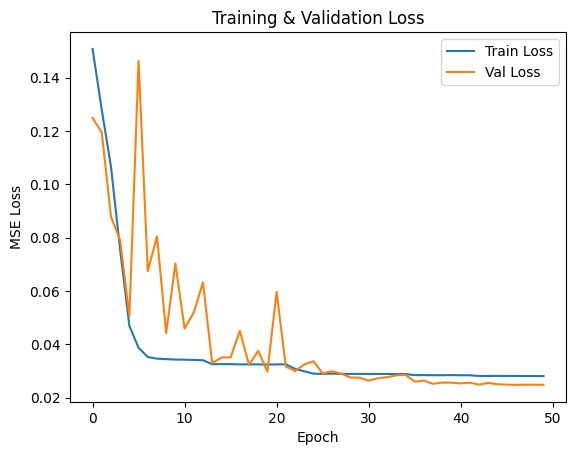


Extracting embeddings for all samples...


C:\Users\hm594\AppData\local\Temp\ipykernel_11812\839016504.py:255: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_modelD.pth"))


Saved embeddings: torch.Size([540278, 128])


In [ ]:


# seeding for reproducability
random.seed(42)

# =====================================================
# HYPERPARAMETERS
# =====================================================
BATCH_SIZE      = 64
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
EPOCHS          = 50
PATIENCE        = 10
BOTTLENECK_DIM  = 128
TRAIN_SPLIT     = 0.8
SUBSET_SIZE     = 540278   # None = full dataset, int = random sample size
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}\n")

# =====================================================
# LOAD DATA
# =====================================================
print("Loading sampled segments and normalization stats...")

with open("bee_samples_with_ids.pkl", "rb") as f:
    data_dict = pickle.load(f)
sampled_segments = np.stack(data_dict["segments"], axis=0)  # (N, 8, 60)
print(f"Raw sample array shape: {sampled_segments.shape}")

with open("bee_norm_stats.pkl", "rb") as f:
    norm_stats = pickle.load(f)
means = norm_stats["mean"]
stds  = norm_stats["std"]

# Normalization
samples_array = (sampled_segments - means[:, None]) / stds[:, None]
print("Data normalized.")

tensor_data = torch.tensor(samples_array, dtype=torch.float32)
print(f"Tensor saved with shape: {tensor_data.shape}")

# Optional subset sampling
if SUBSET_SIZE is not None:
    idx = torch.randperm(tensor_data.size(0))[:SUBSET_SIZE]
    tensor_data = tensor_data[idx]

# =====================================================
# DATASET & SPLIT
# =====================================================
class BeeTrajectoryDataset(Dataset):
    def __init__(self, data_tensor):
        self.data = data_tensor
    def __len__(self):
        return self.data.shape[0]
    def __getitem__(self, idx):
        return self.data[idx]

full_dataset = BeeTrajectoryDataset(tensor_data)
train_size   = int(len(full_dataset) * TRAIN_SPLIT)
val_size     = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Total dataset size: {len(full_dataset)}")
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}\n")

print("--- Training Setup ---")
print(f"Device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}, Validation batches: {len(val_loader)}")
print(f"No. of Epochs: {EPOCHS}")
print("\n----------------------\n")

# =====================================================
# MODEL DEFINITION
# =====================================================
class BeeAutoencoder(nn.Module):
    def __init__(self, bottleneck_dim=BOTTLENECK_DIM):
        super().__init__()
        
        # Encoder
        self.encoder_cnn = nn.Sequential(
            nn.Conv1d(8,   32, 3, stride=2, padding=1), # 60 -> 30
            nn.ReLU(),
            nn.Conv1d(32,  64, 3, stride=2, padding=1), # 30 -> 15
            nn.ReLU(),
            nn.Conv1d(64, 128, 3, stride=2, padding=1), # 15 -> 8
            nn.ReLU(),
            nn.Conv1d(128,256, 3, stride=2, padding=1), # 8  -> 4
            nn.ReLU(),
            nn.Conv1d(256,512, 3, stride=2, padding=1), # 4  -> 2
            nn.ReLU(),
            nn.Conv1d(512,512, 3, stride=2, padding=1)  # 2  -> 1
        )

        # Dynamically compute flat size
        with torch.no_grad():
            test_out = self.encoder_cnn(torch.zeros(1, 8, 60))
        self.flat_size = test_out.numel()

        self.enc_flatten = nn.Flatten()
        self.enc_fc      = nn.Sequential(
            nn.Linear(self.flat_size, bottleneck_dim),
            nn.BatchNorm1d(bottleneck_dim)
        )
        self.dec_fc      = nn.Sequential(
            nn.Linear(bottleneck_dim, self.flat_size),
            nn.ReLU()
        )

        # Decoder (mirrored)
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose1d(512, 512, 3, stride=2, padding=1, output_padding=1), # 1  -> 2
            nn.ReLU(),
            nn.ConvTranspose1d(512, 256, 3, stride=2, padding=1, output_padding=1), # 2  -> 4
            nn.ReLU(),
            nn.ConvTranspose1d(256, 128, 3, stride=2, padding=1, output_padding=1), # 4  -> 8
            nn.ReLU(),
            nn.ConvTranspose1d(128,  64, 3, stride=2, padding=1, output_padding=0), # 8  -> 15
            nn.ReLU(),
            nn.ConvTranspose1d(64,   32, 3, stride=2, padding=1, output_padding=1), # 15 -> 30
            nn.ReLU(),
            nn.ConvTranspose1d(32,    8, 4, stride=2, padding=1, output_padding=0)  # 30 -> 60
        )

    def encode(self, x):
        x = self.encoder_cnn(x)
        x = self.enc_flatten(x)
        return self.enc_fc(x)

    def decode(self, z):
        z = self.dec_fc(z)
        z = z.view(z.size(0), 512, -1)  # auto-infer seq length
        return self.decoder_cnn(z)

    def forward(self, x):
        z = self.encode(x)
        out = self.decode(z)
        return out, z

# =====================================================
# TRAINING SETUP
# =====================================================
model      = BeeAutoencoder().to(DEVICE)
criterion  = nn.SmoothL1Loss()
optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# SCHEDULER
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)

train_losses, val_losses = [], []
best_val_loss            = float('inf')
epochs_no_improve        = 0
prev_train_loss          = None
start_total              = time.time()


print("Starting training...\n")

# =====================================================
# TRAINING LOOP
# =====================================================
for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        output, _ = model(batch)
        loss = criterion(output, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            output, _ = model(batch)
            loss = criterion(output, batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Step the LR scheduler
    scheduler.step(val_loss)    

    # Track change in train loss
    if prev_train_loss is None:
        loss_change = "N/A"
    else:
        diff = ((train_loss - prev_train_loss) / prev_train_loss) * 100
        loss_change = f"{diff:+.1f}%"
    prev_train_loss = train_loss

    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_modelD.pth")
        improved = "✔"
        epochs_no_improve = 0
    else:
        improved = ""
        epochs_no_improve += 1

    # ETA
    epoch_time = time.time() - start_time
    eta = timedelta(seconds=(EPOCHS - epoch - 1) * epoch_time)

    # Logging
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
        f"Train: {train_loss:.4f} ({loss_change}) | "
        f"Val: {val_loss:.4f} {improved} | "
        f"Best: {best_val_loss:.4f} | "
        f"Time: {epoch_time:.2f}s | ETA: {eta}"
    )

    if epochs_no_improve >= PATIENCE:
        print("Early stopping triggered.")
        break

total_time = timedelta(seconds=time.time() - start_total)
print(f"\nTraining completed in {total_time}. Best Val Loss: {best_val_loss:.4f}")
print("\nModel saved to 'best_modelD.pth'.")

# =====================================================
# LOSS CURVE
# =====================================================
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Smooth L1 Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.savefig("loss_curveD.png")
plt.show()

# =====================================================
# SAVE EMBEDDINGS
# =====================================================
print("\nExtracting embeddings for all samples...")
model.load_state_dict(torch.load("best_modelD.pth"))
model.eval()
all_embeddings = []
with torch.no_grad():
    for i in range(0, len(full_dataset), BATCH_SIZE):
        batch = tensor_data[i:i+BATCH_SIZE].to(DEVICE)
        z = model.encode(batch)
        all_embeddings.append(z.cpu())
all_embeddings = torch.cat(all_embeddings, dim=0)
torch.save(all_embeddings, "final_embeddingsD.pt")
print(f"Saved embeddings: {all_embeddings.shape}")


=====================================================
# VISUALIZE INPUT vs RECONSTRUCTION FOR A FEW SAMPLES
=====================================================

C:\Users\hm594\AppData\local\Temp\ipykernel_11812\2769200752.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_modelD.pth", map_loc

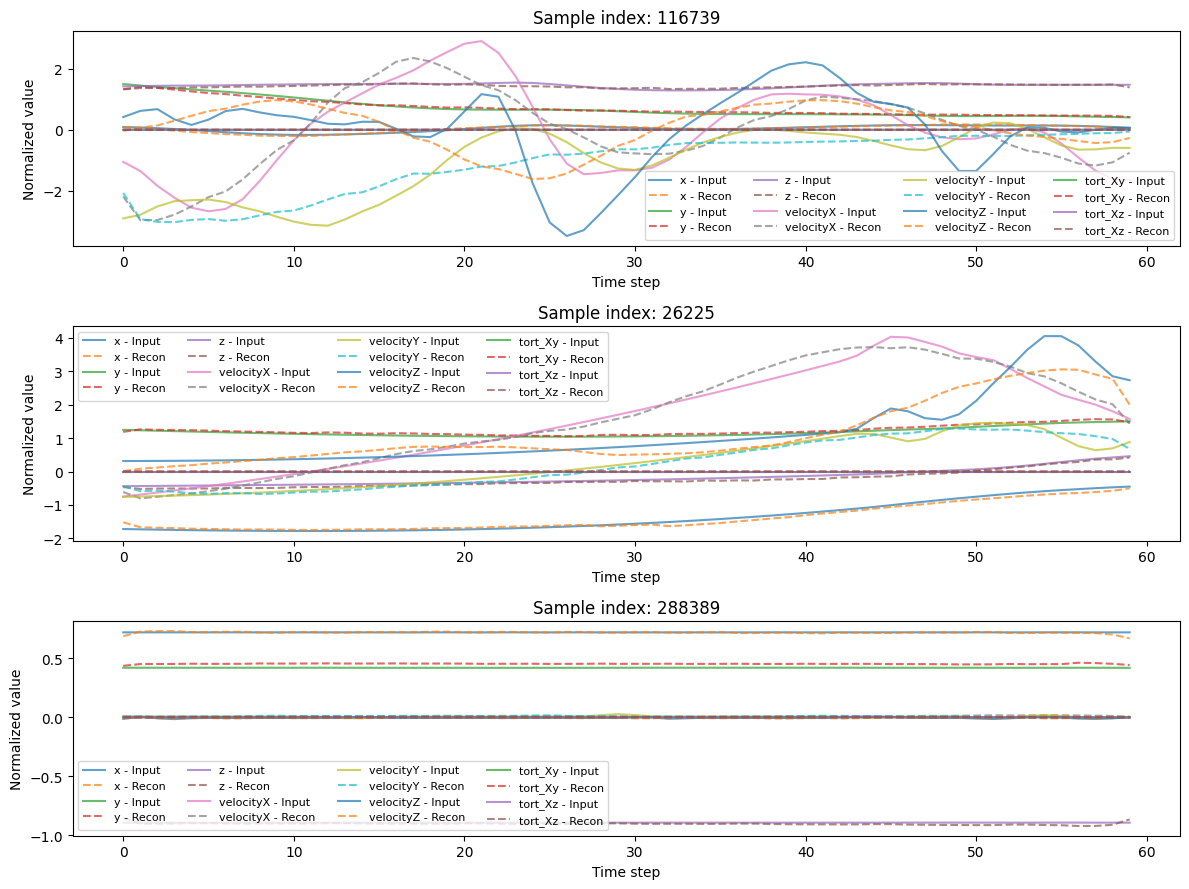

In [60]:
# =====================================================
# VISUALIZE INPUT vs RECONSTRUCTION FOR A FEW SAMPLES
# =====================================================
import random
import matplotlib.pyplot as plt
import torch

# Define feature names
feature_names = ['x', 'y', 'z', 'velocityX', 'velocityY', 'velocityZ', 'tort_Xy', 'tort_Xz']

# Load best model
model.load_state_dict(torch.load("best_modelD.pth", map_location=DEVICE))
model.eval()

# Pick random sample indices
num_samples = 3
indices = random.sample(range(len(full_dataset)), num_samples)

fig, axes = plt.subplots(num_samples, 1, figsize=(12, 3 * num_samples))

if num_samples == 1:
    axes = [axes]  # ensure iterable

for ax, idx in zip(axes, indices):
    inp = full_dataset[idx].unsqueeze(0).to(DEVICE)  # (1, 8, 60)
    with torch.no_grad():
        out, _ = model(inp)

    inp = inp.squeeze(0).cpu().numpy()   # (8, 60)
    out = out.squeeze(0).cpu().numpy()   # (8, 60)

    # Plot all features with names
    for feat in range(inp.shape[0]):
        ax.plot(inp[feat], label=f"{feature_names[feat]} - Input", alpha=0.7)
        ax.plot(out[feat], '--', label=f"{feature_names[feat]} - Recon", alpha=0.7)

    ax.set_title(f"Sample index: {idx}")
    ax.legend(ncol=4, fontsize=8)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Normalized value")

plt.tight_layout()
plt.show()


normalised data

C:\Users\hm594\AppData\local\Temp\ipykernel_11812\1341992669.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_modelD.pth", map_loca

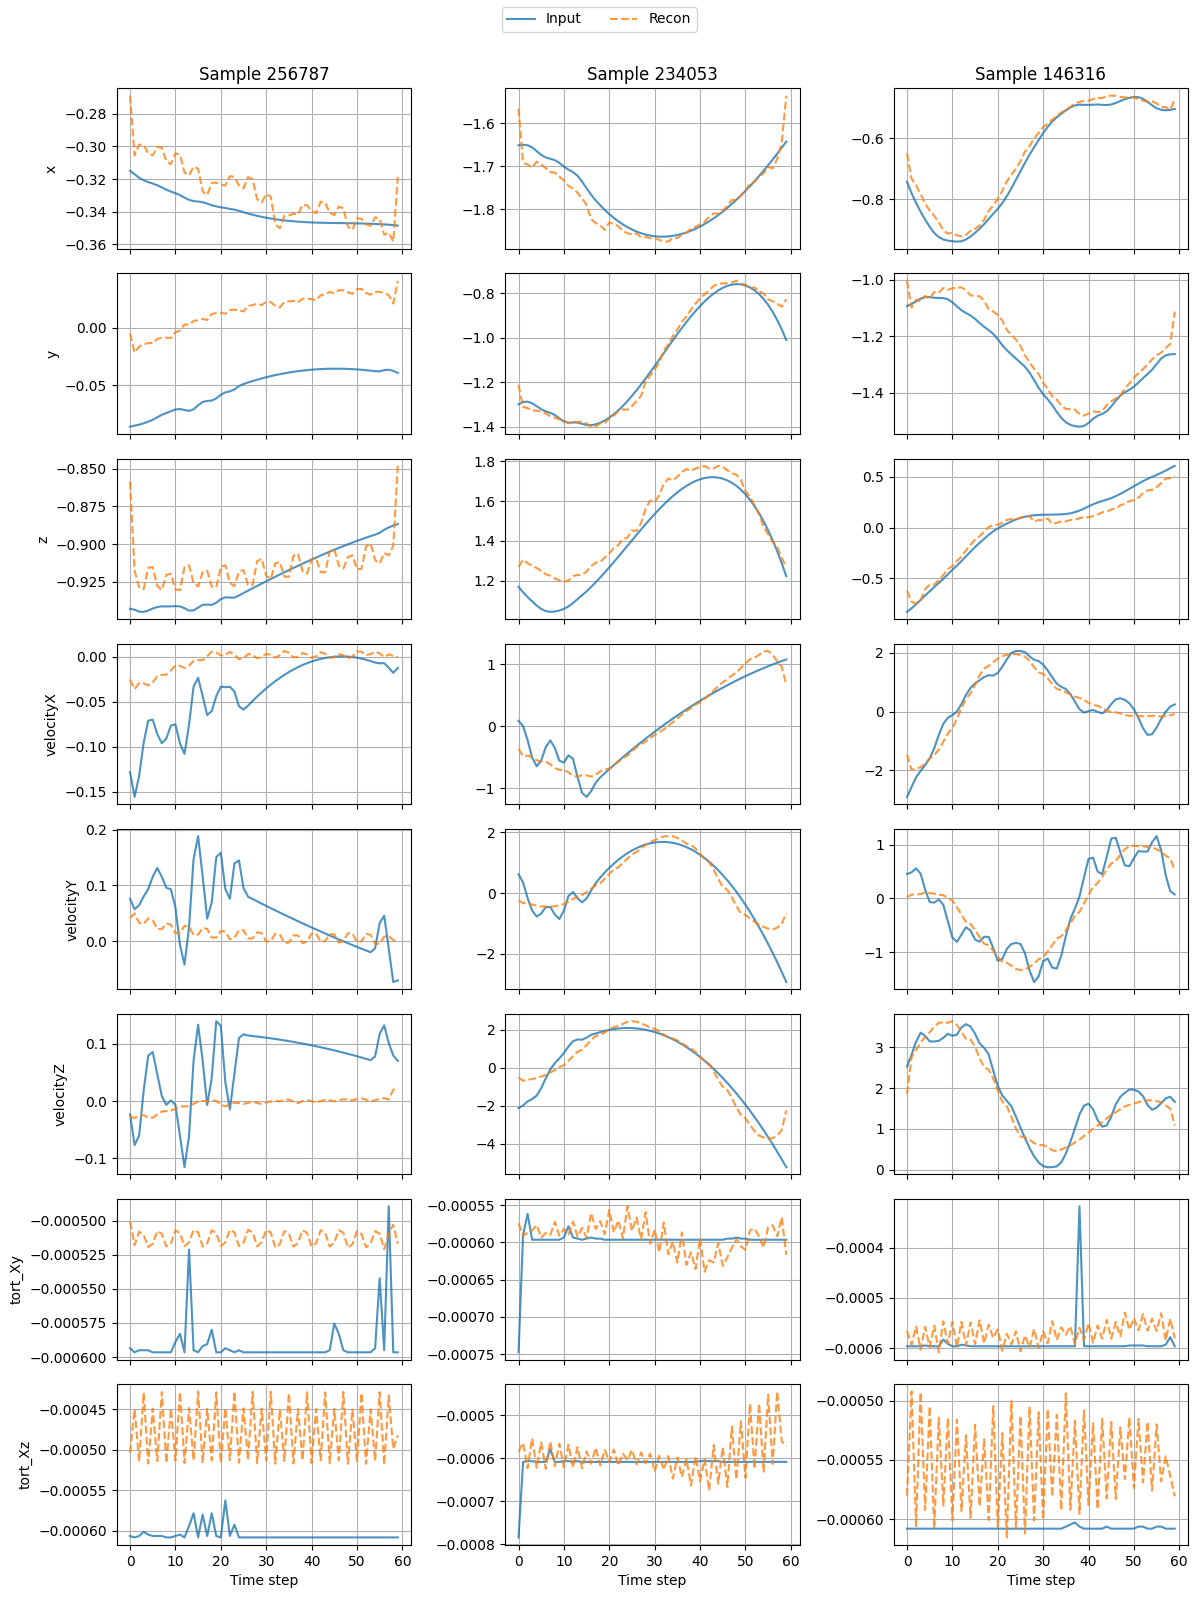

In [61]:
# =====================================================
# VISUALIZE INPUT vs RECONSTRUCTION - FEATURE-WISE
# =====================================================
import random
import matplotlib.pyplot as plt
import torch

# Load best model
model.load_state_dict(torch.load("best_modelD.pth", map_location=DEVICE))
model.eval()

# Pick random sample indices
num_samples = 3
indices = random.sample(range(len(full_dataset)), num_samples)

feature_names = ['x', 'y', 'z', 'velocityX', 'velocityY', 'velocityZ', 'tort_Xy', 'tort_Xz']

fig, axes = plt.subplots(8, num_samples, figsize=(4 * num_samples, 16), sharex=True)

if num_samples == 1:
    axes = axes.reshape(-1, 1)  # Ensure 2D array for consistent indexing

for col, idx in enumerate(indices):
    inp = full_dataset[idx].unsqueeze(0).to(DEVICE)  # (1, 8, 60)
    with torch.no_grad():
        out, _ = model(inp)

    inp = inp.squeeze(0).cpu().numpy()   # (8, 60)
    out = out.squeeze(0).cpu().numpy()   # (8, 60)

    for feat in range(inp.shape[0]):
        ax = axes[feat, col]
        ax.plot(inp[feat], label="Input", alpha=0.8)
        ax.plot(out[feat], '--', label="Recon", alpha=0.8)
        if col == 0:
            ax.set_ylabel(feature_names[feat])
        if feat == 0:
            ax.set_title(f"Sample {idx}")
        ax.grid(True)
        if feat == inp.shape[0] - 1:
            ax.set_xlabel("Time step")

# Add legend only once
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


un normalized data

C:\Users\hm594\AppData\local\Temp\ipykernel_11812\3527679672.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_modelD.pth", map_loc

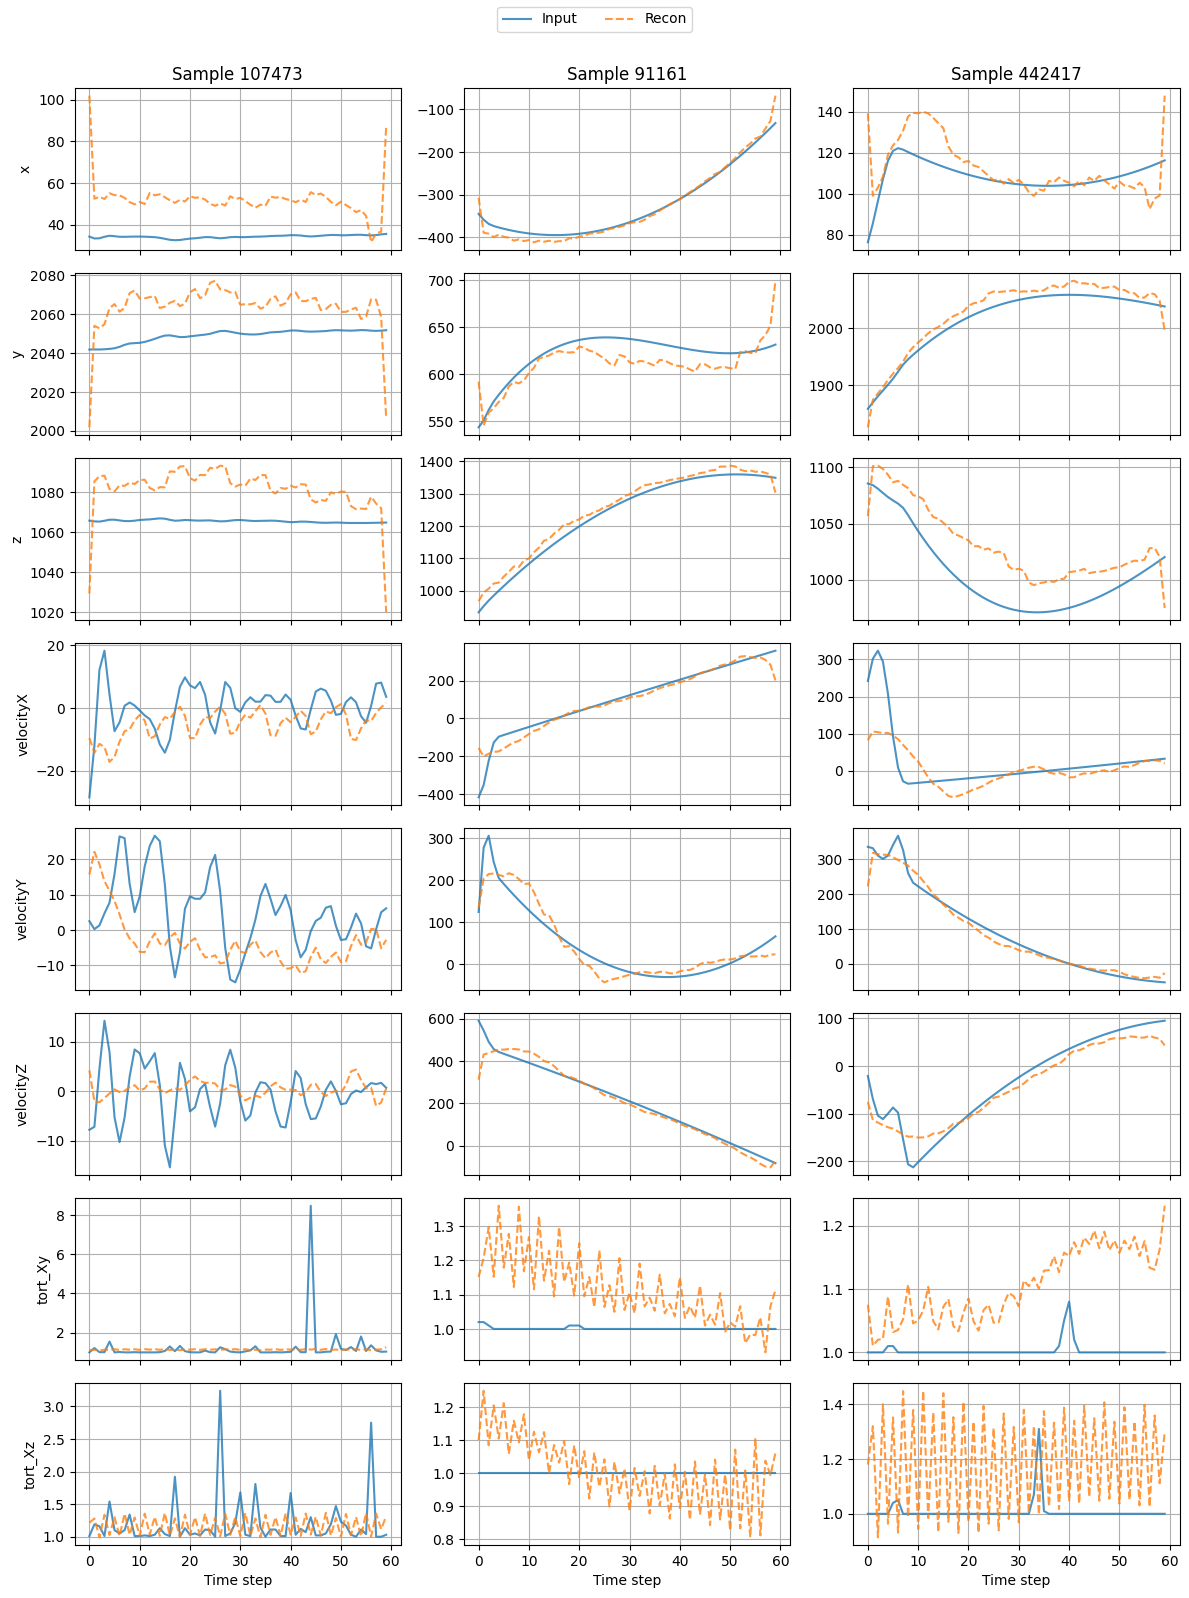

In [62]:
import random
import matplotlib.pyplot as plt
import torch

# Load normalization stats
import pickle
with open("bee_norm_stats.pkl", "rb") as f:
    norm_stats = pickle.load(f)
means = norm_stats["mean"]  # shape: (8,)
stds  = norm_stats["std"]   # shape: (8,)

feature_names = ['x', 'y', 'z', 'velocityX', 'velocityY', 'velocityZ', 'tort_Xy', 'tort_Xz']

# Load best model
model.load_state_dict(torch.load("best_modelD.pth", map_location=DEVICE))
model.eval()

# Pick random sample indices
num_samples = 3
indices = random.sample(range(len(full_dataset)), num_samples)

fig, axes = plt.subplots(8, num_samples, figsize=(4 * num_samples, 16), sharex=True)

if num_samples == 1:
    axes = axes.reshape(-1, 1)  # Ensure 2D array for consistent indexing

for col, idx in enumerate(indices):
    inp = full_dataset[idx].unsqueeze(0).to(DEVICE)  # normalized (1, 8, 60)
    with torch.no_grad():
        out, _ = model(inp)

    inp = inp.squeeze(0).cpu().numpy()   # (8, 60)
    out = out.squeeze(0).cpu().numpy()   # (8, 60)

    # Reverse normalization: x_orig = x_norm * std + mean
    inp_unnorm = inp * stds[:, None] + means[:, None]
    out_unnorm = out * stds[:, None] + means[:, None]

    for feat in range(inp.shape[0]):
        ax = axes[feat, col]
        ax.plot(inp_unnorm[feat], label="Input", alpha=0.8)
        ax.plot(out_unnorm[feat], '--', label="Recon", alpha=0.8)
        if col == 0:
            ax.set_ylabel(feature_names[feat])
        if feat == 0:
            ax.set_title(f"Sample {idx}")
        ax.grid(True)
        if feat == inp.shape[0] - 1:
            ax.set_xlabel("Time step")

# Add legend only once
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


---
sanity checks


C:\Users\hm594\AppData\local\Temp\ipykernel_11812\617343798.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embeddings = torch.load("final_embeddingsD.pt").numpy()


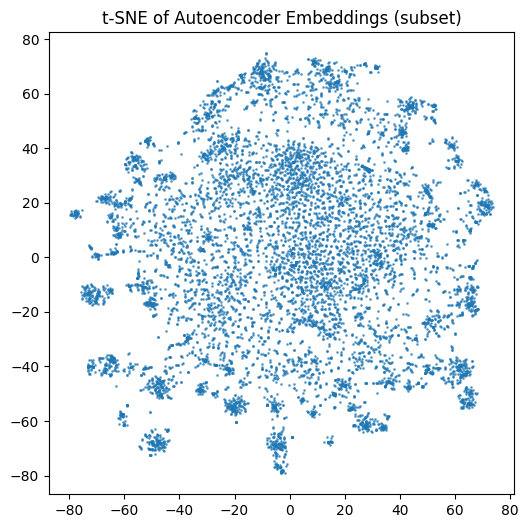

c:\Users\hm594\Documents\SCRIPTS\docs\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


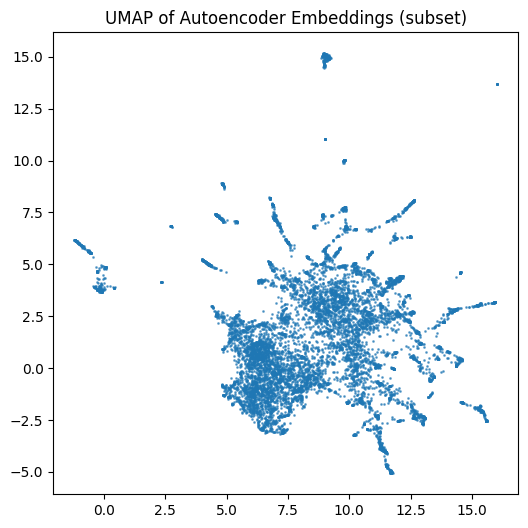

In [63]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

# Load embeddings
embeddings = torch.load("final_embeddingsD.pt").numpy()

# Sample subset for visualization
subset_size = 10000
indices = np.random.choice(embeddings.shape[0], subset_size, replace=False)
embeddings_subset = embeddings[indices]

# t-SNE
tsne_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(embeddings_subset)
plt.figure(figsize=(6, 6))
plt.scatter(tsne_2d[:,0], tsne_2d[:,1], s=1, alpha=0.6)
plt.title("t-SNE of Autoencoder Embeddings (subset)")
plt.show()

# UMAP
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(embeddings_subset)
plt.figure(figsize=(6, 6))
plt.scatter(umap_2d[:,0], umap_2d[:,1], s=1, alpha=0.6)
plt.title("UMAP of Autoencoder Embeddings (subset)")
plt.show()


Embedding Similarity Test
Checks if similar samples have close embeddings.
You’ll need a notion of "similar" 
 e.g., temporally close samples.

In [64]:
from torch.nn.functional import cosine_similarity

# Take two close samples
a = torch.tensor(embeddings[0])
b = torch.tensor(embeddings[1])
sim_close = cosine_similarity(a, b, dim=0).item()

# Take two far-apart samples
c = torch.tensor(embeddings[0])
d = torch.tensor(embeddings[-1])
sim_far = cosine_similarity(c, d, dim=0).item()

print("Similarity (close samples):", sim_close)
print("Similarity (far samples):", sim_far)


Similarity (close samples): -0.5087279677391052
Similarity (far samples): -0.2938555181026459


# ===============================================
# Clustering
# ===============================================

@K-means using elbow and silhouette method to find 'k' value


=== STEP 1: Loading embeddings ===
[INFO] Loaded embeddings of shape (540278, 128)

=== STEP 2: Creating subset for K estimation ===
[INFO] Using subset of 50000 samples for elbow/silhouette analysis

=== STEP 3: Running Elbow & Silhouette Analysis ===
  -> Fitting MiniBatchKMeans for k=2 ... 

C:\Users\hm594\AppData\local\Temp\ipykernel_11812\2578368017.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embeddings = torch.load("final_embeddingsD.pt")  # shape: (

done in 42.95s | inertia=380874.53, silhouette=0.1628
  -> Fitting MiniBatchKMeans for k=3 ... done in 49.79s | inertia=371902.09, silhouette=0.1290
  -> Fitting MiniBatchKMeans for k=4 ... done in 43.33s | inertia=333696.56, silhouette=0.1389
  -> Fitting MiniBatchKMeans for k=5 ... done in 49.87s | inertia=322043.44, silhouette=0.1308
  -> Fitting MiniBatchKMeans for k=6 ... done in 42.59s | inertia=315943.94, silhouette=0.1302
  -> Fitting MiniBatchKMeans for k=7 ... done in 49.79s | inertia=308147.59, silhouette=0.1188
  -> Fitting MiniBatchKMeans for k=8 ... done in 44.11s | inertia=301423.06, silhouette=0.1207
  -> Fitting MiniBatchKMeans for k=9 ... done in 50.94s | inertia=288104.50, silhouette=0.1309
  -> Fitting MiniBatchKMeans for k=10 ... done in 44.03s | inertia=283504.25, silhouette=0.1333
  -> Fitting MiniBatchKMeans for k=11 ... done in 49.75s | inertia=280590.28, silhouette=0.1336
  -> Fitting MiniBatchKMeans for k=12 ... done in 44.36s | inertia=277320.69, silhouette=

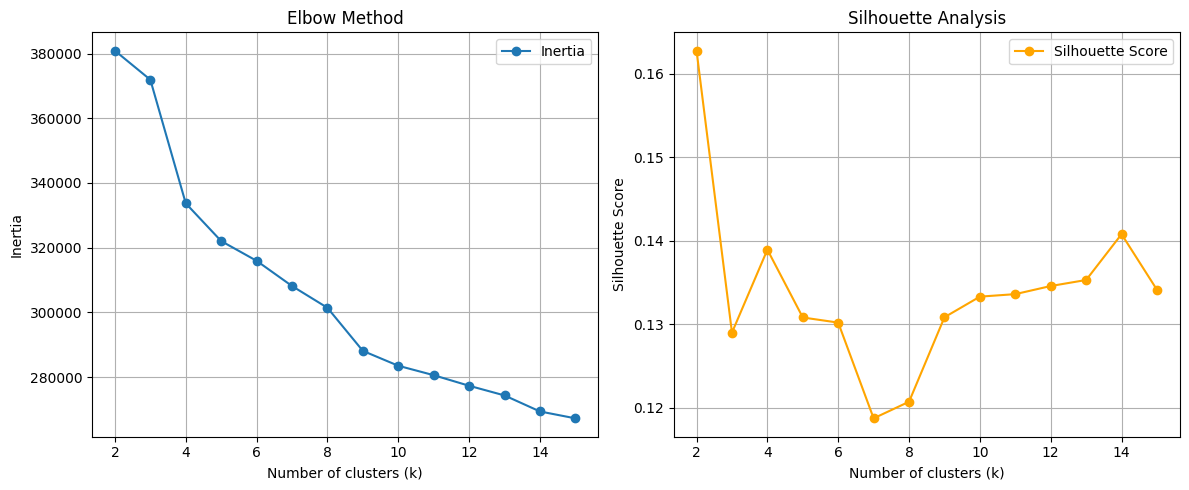

In [75]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import time
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

start_total = time.time()

print("\n=== STEP 1: Loading embeddings ===")
embeddings = torch.load("final_embeddingsD.pt")  # shape: (N, bottleneck_dim)
embeddings_np = embeddings.numpy()
print(f"[INFO] Loaded embeddings of shape {embeddings_np.shape}")

# =====================================================
# SUBSAMPLE FOR K ESTIMATION
# =====================================================
print("\n=== STEP 2: Creating subset for K estimation ===")
SAMPLE_SIZE = 50000
subset_idx = np.random.choice(len(embeddings_np), size=SAMPLE_SIZE, replace=False)
subset_embeddings = embeddings_np[subset_idx]
print(f"[INFO] Using subset of {SAMPLE_SIZE} samples for elbow/silhouette analysis")

# =====================================================
# ELBOW & SILHOUETTE METHOD
# =====================================================
print("\n=== STEP 3: Running Elbow & Silhouette Analysis ===")
k_values = range(2, 16)
inertia_scores = []
silhouette_scores = []

start_analysis = time.time()
for k in k_values:
    step_start = time.time()
    print(f"  -> Fitting MiniBatchKMeans for k={k} ...", end=" ", flush=True)
    
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
    kmeans.fit(subset_embeddings)
    inertia_scores.append(kmeans.inertia_)
    
    sil_score = silhouette_score(subset_embeddings, kmeans.labels_)
    silhouette_scores.append(sil_score)
    
    print(f"done in {time.time()-step_start:.2f}s | inertia={inertia_scores[-1]:.2f}, silhouette={sil_score:.4f}")

print(f"[INFO] Elbow & Silhouette analysis completed in {time.time()-start_analysis:.2f}s")

# =====================================================
# PLOT RESULTS
# =====================================================
print("\n=== STEP 4: Plotting results ===")
plt.figure(figsize=(12,5))

# Elbow plot
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia_scores, 'o-', label='Inertia')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.legend()

# Silhouette plot
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, 'o-', color='orange', label='Silhouette Score')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


In [66]:

# =====================================================
# CHOOSE K AND CLUSTER FULL DATA
# =====================================================
BEST_K = 6  # <-- change after inspecting plots
print(f"\n=== STEP 5: Clustering full dataset with k={BEST_K} ===")
start_full = time.time()
final_kmeans = MiniBatchKMeans(n_clusters=BEST_K, random_state=42, batch_size=2048)
cluster_labels = final_kmeans.fit_predict(embeddings_np)
print(f"[INFO] Full dataset clustering done in {time.time()-start_full:.2f}s")

# =====================================================
# SAVE LABELS
# =====================================================
print("\n=== STEP 6: Saving cluster labels ===")
np.save("cluster_labels6_11.npy", cluster_labels)
print(f"[INFO] Cluster labels saved to cluster_labels6_11.npy with shape {cluster_labels.shape}")

# =====================================================
# RUNTIME SUMMARY
# =====================================================
print(f"\n[SUMMARY] Total runtime: {time.time()-start_total:.2f}s")



=== STEP 5: Clustering full dataset with k=6 ===
[INFO] Full dataset clustering done in 2.00s

=== STEP 6: Saving cluster labels ===
[INFO] Cluster labels saved to cluster_labels6_11.npy with shape (540278,)

[SUMMARY] Total runtime: 735.86s


In [67]:


# ----------------------------
# STEP 1: Load embeddings
# ----------------------------
start_total = time.time()
print("\n=== STEP 1: Loading embeddings ===")
embeddings = torch.load("final_embeddingsD.pt")  # shape: (540278, bottleneck_dim)
embeddings_np = embeddings.numpy()
print(f"[INFO] Loaded embeddings of shape {embeddings_np.shape}")

# ----------------------------
# STEP 2: Cluster full dataset
# ----------------------------
BEST_K = 6
print(f"\n=== STEP 2: Clustering full dataset with k={BEST_K} ===")
start_cluster = time.time()
kmeans = MiniBatchKMeans(n_clusters=BEST_K, random_state=42, batch_size=2048)
cluster_labels = kmeans.fit_predict(embeddings_np)
print(f"[INFO] Clustering completed in {time.time() - start_cluster:.2f}s")

# ----------------------------
# STEP 3: Cluster statistics
# ----------------------------
print("\n=== STEP 3: Cluster statistics ===")
unique, counts = np.unique(cluster_labels, return_counts=True)
total_points = len(cluster_labels)

for lbl, cnt in zip(unique, counts):
    perc = (cnt / total_points) * 100
    print(f"Cluster {lbl}: {cnt} samples ({perc:.2f}%)")

# ----------------------------
# STEP 4: Load bee IDs
# ----------------------------
print("\n=== STEP 4: Loading bee IDs ===")
with open("bee_samples_with_ids.pkl", "rb") as f:
    data_dict = pickle.load(f)
bee_ids = np.array(data_dict["bee_ids"])  # Assuming "ids" holds bee IDs

if len(bee_ids) != len(cluster_labels):
    raise ValueError(f"Length mismatch: {len(bee_ids)} IDs vs {len(cluster_labels)} cluster labels")

# ----------------------------
# STEP 5: Save mapping CSV
# ----------------------------
print("\n=== STEP 5: Saving cluster-bee mapping CSV ===")
df_map = pd.DataFrame({
    "sample_index": np.arange(len(cluster_labels)),
    "bee_id": bee_ids,
    "cluster_id": cluster_labels
})
df_map.to_csv("bee_cluster_map_6_11.csv", index=False)
print(f"[INFO] Mapping saved to bee_cluster_map_6_11.csv with shape {df_map.shape}")

# ----------------------------
# SUMMARY
# ----------------------------
print(f"\n[SUMMARY] Total runtime: {time.time() - start_total:.2f}s")



=== STEP 1: Loading embeddings ===
[INFO] Loaded embeddings of shape (540278, 128)

=== STEP 2: Clustering full dataset with k=6 ===


C:\Users\hm594\AppData\local\Temp\ipykernel_11812\4179165665.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  embeddings = torch.load("final_embeddingsD.pt")  # shape: (5

[INFO] Clustering completed in 1.84s

=== STEP 3: Cluster statistics ===
Cluster 0: 60135 samples (11.13%)
Cluster 1: 137839 samples (25.51%)
Cluster 2: 72921 samples (13.50%)
Cluster 3: 105181 samples (19.47%)
Cluster 4: 67078 samples (12.42%)
Cluster 5: 97124 samples (17.98%)

=== STEP 4: Loading bee IDs ===

=== STEP 5: Saving cluster-bee mapping CSV ===
[INFO] Mapping saved to bee_cluster_map_6_11.csv with shape (540278, 3)

[SUMMARY] Total runtime: 13.92s


Visualising clusters in 2D for a subset of dataset

t-SNE for 5000 samples

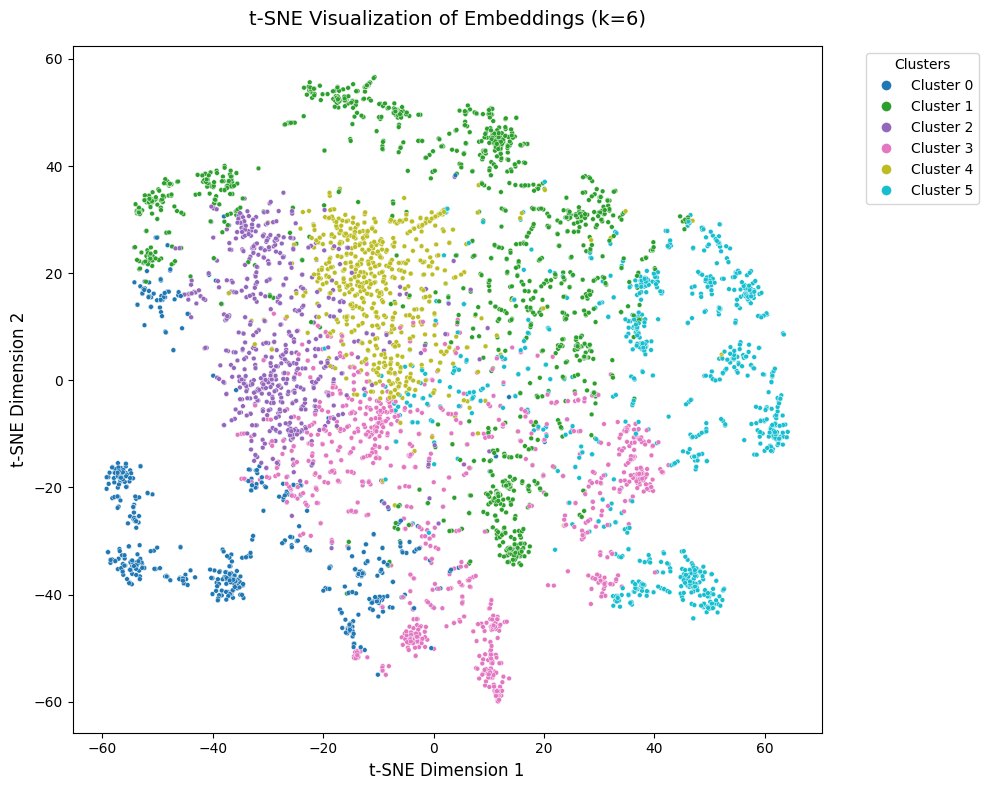

In [69]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Random sample for visualization
SAMPLE_SIZE = 5000
subset_idx = np.random.choice(len(embeddings_np), size=SAMPLE_SIZE, replace=False)
subset_embeddings = embeddings_np[subset_idx]
subset_labels = cluster_labels[subset_idx]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(subset_embeddings)



# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    tsne_results[:, 0], tsne_results[:, 1],
    c=subset_labels, cmap='tab10',
    s=12, edgecolor='white', linewidth=0.3
)

# Axis labels
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.title(f"t-SNE Visualization of Embeddings (k={BEST_K})", fontsize=14, pad=15)

# Legend (one color per cluster)
unique_labels = np.unique(subset_labels)
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=scatter.cmap(scatter.norm(l)),
                      markersize=8) for l in unique_labels]
plt.legend(handles, [f"Cluster {l}" for l in unique_labels],
           title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


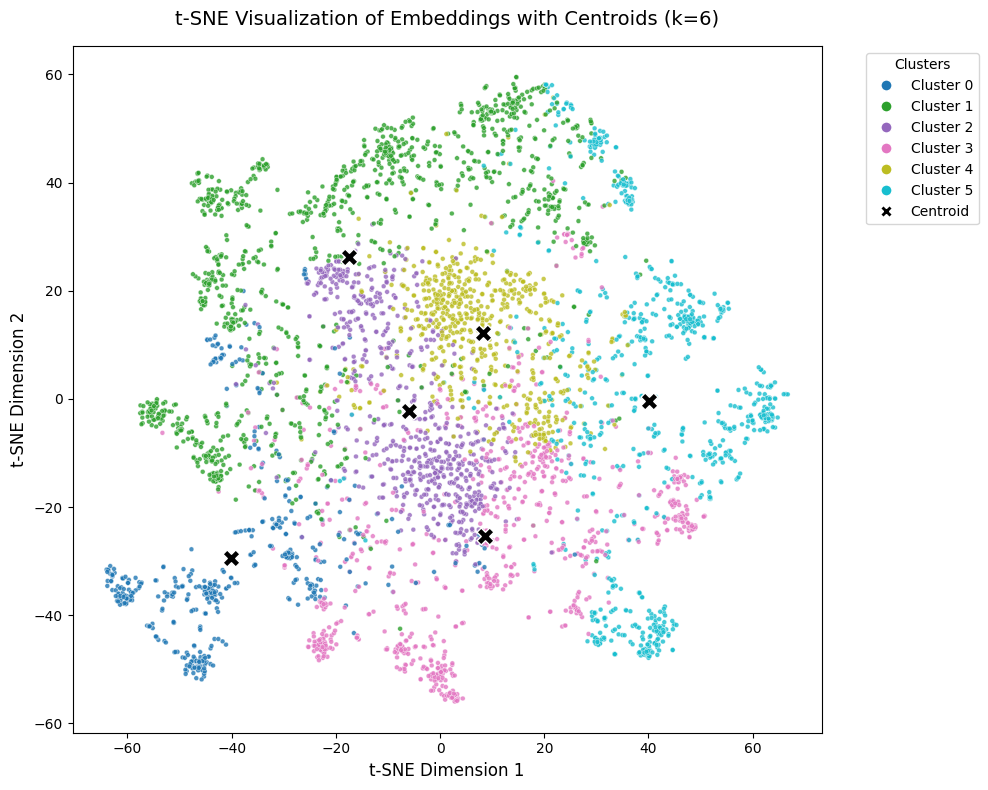

In [70]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Random sample for visualization
SAMPLE_SIZE = 5000
subset_idx = np.random.choice(len(embeddings_np), size=SAMPLE_SIZE, replace=False)
subset_embeddings = embeddings_np[subset_idx]
subset_labels = cluster_labels[subset_idx]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(subset_embeddings)

# Compute cluster centroids in t-SNE space
centroids = []
for c in range(BEST_K):
    mask = subset_labels == c
    centroids.append(tsne_results[mask].mean(axis=0))
centroids = np.array(centroids)

# Plot points
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    tsne_results[:, 0], tsne_results[:, 1],
    c=subset_labels, cmap='tab10', s=12, edgecolor='white', linewidth=0.3, alpha=0.8
)

# Plot centroids
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    c='black', s=150, marker='X', edgecolor='white', linewidth=1.0, label='Centroid'
)

# Labels, legend, and title
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.title(f"t-SNE Visualization of Embeddings with Centroids (k={BEST_K})", fontsize=14, pad=15)

# Legend for clusters + centroids
unique_labels = np.unique(subset_labels)
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=scatter.cmap(scatter.norm(l)), markersize=8)
    for l in unique_labels
]
plt.legend(
    handles + [plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=8)],
    [f"Cluster {l}" for l in unique_labels] + ["Centroid"],
    title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left'
)

plt.tight_layout()
plt.show()


UMAP for 5000 sampeles

c:\Users\hm594\Documents\SCRIPTS\docs\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


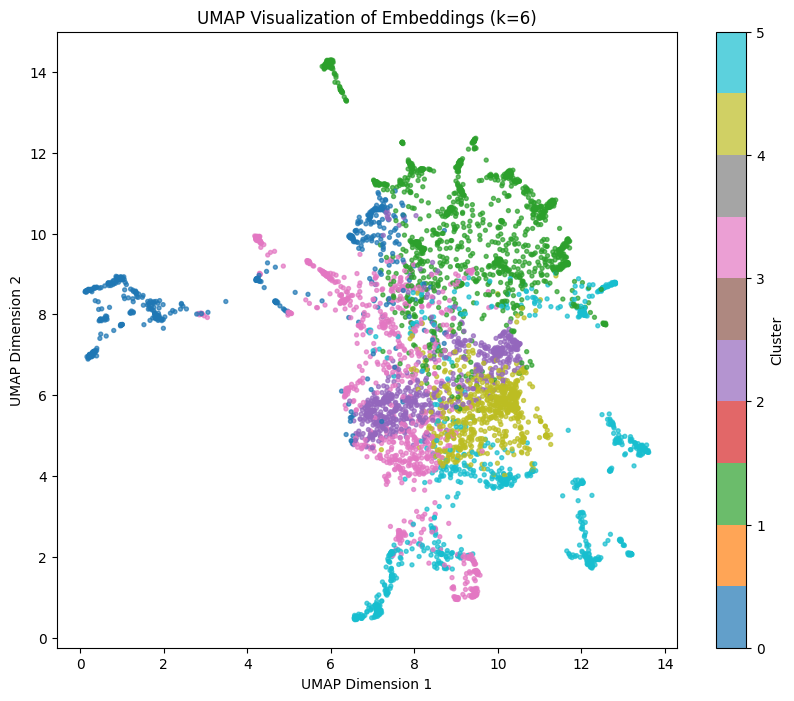

In [71]:
import umap.umap_ as umap

# Subsample for speed
SAMPLE_SIZE = 5000
subset_idx = np.random.choice(len(embeddings_np), size=SAMPLE_SIZE, replace=False)
subset_embeddings = embeddings_np[subset_idx]
subset_labels = cluster_labels[subset_idx]

# Run UMAP
umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42)
umap_results = umap_model.fit_transform(subset_embeddings)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_results[:, 0], umap_results[:, 1],
                      c=subset_labels, cmap='tab10', s=8, alpha=0.7)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title(f"UMAP Visualization of Embeddings (k={BEST_K})")
plt.colorbar(scatter, ticks=range(BEST_K), label='Cluster')
plt.show()


t-SNE for 20000 samples

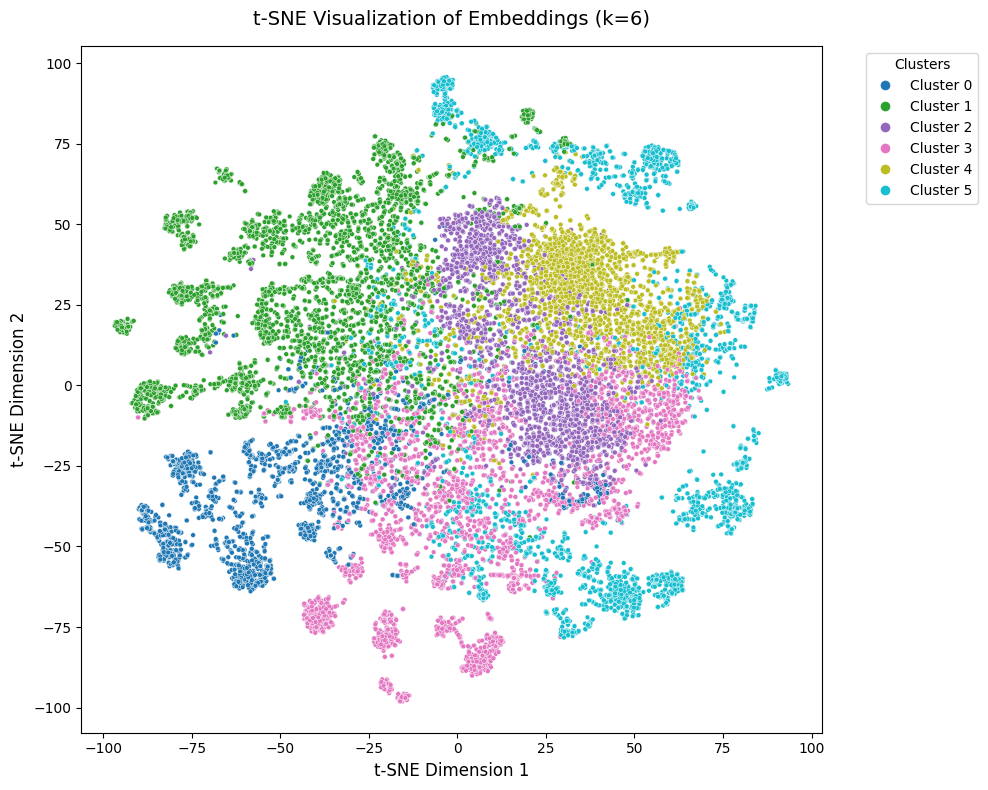

In [72]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Random sample for visualization
SAMPLE_SIZE = 20000
subset_idx = np.random.choice(len(embeddings_np), size=SAMPLE_SIZE, replace=False)
subset_embeddings = embeddings_np[subset_idx]
subset_labels = cluster_labels[subset_idx]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(subset_embeddings)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    tsne_results[:, 0], tsne_results[:, 1],
    c=subset_labels, cmap='tab10',
    s=12, edgecolor='white', linewidth=0.3
)

# Axis labels
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.title(f"t-SNE Visualization of Embeddings (k={BEST_K})", fontsize=14, pad=15)

# Legend (one color per cluster)
unique_labels = np.unique(subset_labels)
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=scatter.cmap(scatter.norm(l)),
                      markersize=8) for l in unique_labels]
plt.legend(handles, [f"Cluster {l}" for l in unique_labels],
           title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


UMAP for 20000 samples

c:\Users\hm594\Documents\SCRIPTS\docs\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


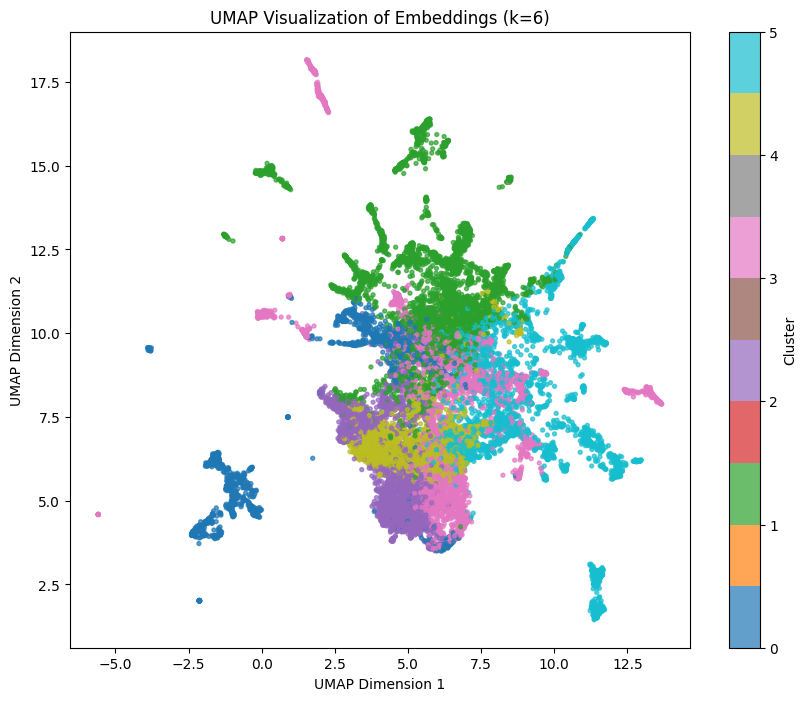

In [73]:
import umap.umap_ as umap

# Subsample for speed
SAMPLE_SIZE = 20000
subset_idx = np.random.choice(len(embeddings_np), size=SAMPLE_SIZE, replace=False)
subset_embeddings = embeddings_np[subset_idx]
subset_labels = cluster_labels[subset_idx]

# Run UMAP
umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42)
umap_results = umap_model.fit_transform(subset_embeddings)

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(umap_results[:, 0], umap_results[:, 1],
                      c=subset_labels, cmap='tab10', s=8, alpha=0.7)
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title(f"UMAP Visualization of Embeddings (k={BEST_K})")
plt.colorbar(scatter, ticks=range(BEST_K), label='Cluster')
plt.show()


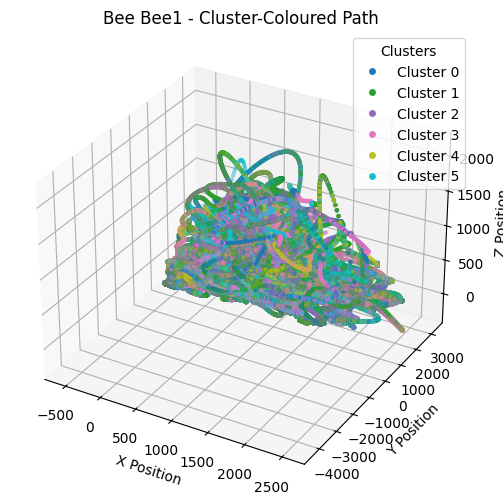

In [74]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# === Load data ===
with open("bee_samples_with_ids.pkl", "rb") as f:
    data_dict = pickle.load(f)

# Segments (N, 8, 60)
segments = np.stack(data_dict["segments"], axis=0)

# Bee IDs (length N, one per segment)
bee_ids = np.array(data_dict["bee_ids"])  # Adjust key if different

# Cluster labels from k=6 clustering
cluster_labels = np.load("cluster_labels6_11.npy")

# === Plot function ===
def plot_bee_cluster_path(bee_id, xyz_indices=(0, 1, 2)):
    """
    Plots the full trajectory of a given bee,
    colour-coded by cluster assignment for each segment.
    """
    # Get all segments for this bee
    bee_mask = bee_ids == bee_id
    bee_segments = segments[bee_mask]  # Shape: (num_segments, 8, 60)
    bee_clusters = cluster_labels[bee_mask]  # Shape: (num_segments,)

    if bee_segments.size == 0:
        print(f"No data found for bee ID: {bee_id}")
        return

    # Concatenate all points into a continuous path
    xs, ys, zs, cs = [], [], [], []
    for seg, c in zip(bee_segments, bee_clusters):
        x = seg[xyz_indices[0]]
        y = seg[xyz_indices[1]]
        z = seg[xyz_indices[2]]

        xs.extend(x)
        ys.extend(y)
        zs.extend(z)
        cs.extend([c] * len(x))

    # Plot 3D path with colour-coded clusters
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(xs, ys, zs, c=cs, cmap='tab10', s=5)

    ax.set_title(f"Bee {bee_id} - Cluster-Coloured Path")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.set_zlabel("Z Position")

    # Add legend
    unique_clusters = np.unique(cs)
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                          markerfacecolor=scatter.cmap(scatter.norm(l)),
                          markersize=6) for l in unique_clusters]
    ax.legend(handles, [f"Cluster {l}" for l in unique_clusters],
              title="Clusters", loc='best')

    plt.show()

# === Example usage ===
example_bee_id = bee_ids[0]  # First bee in dataset
plot_bee_cluster_path(example_bee_id, xyz_indices=(0, 1, 2))


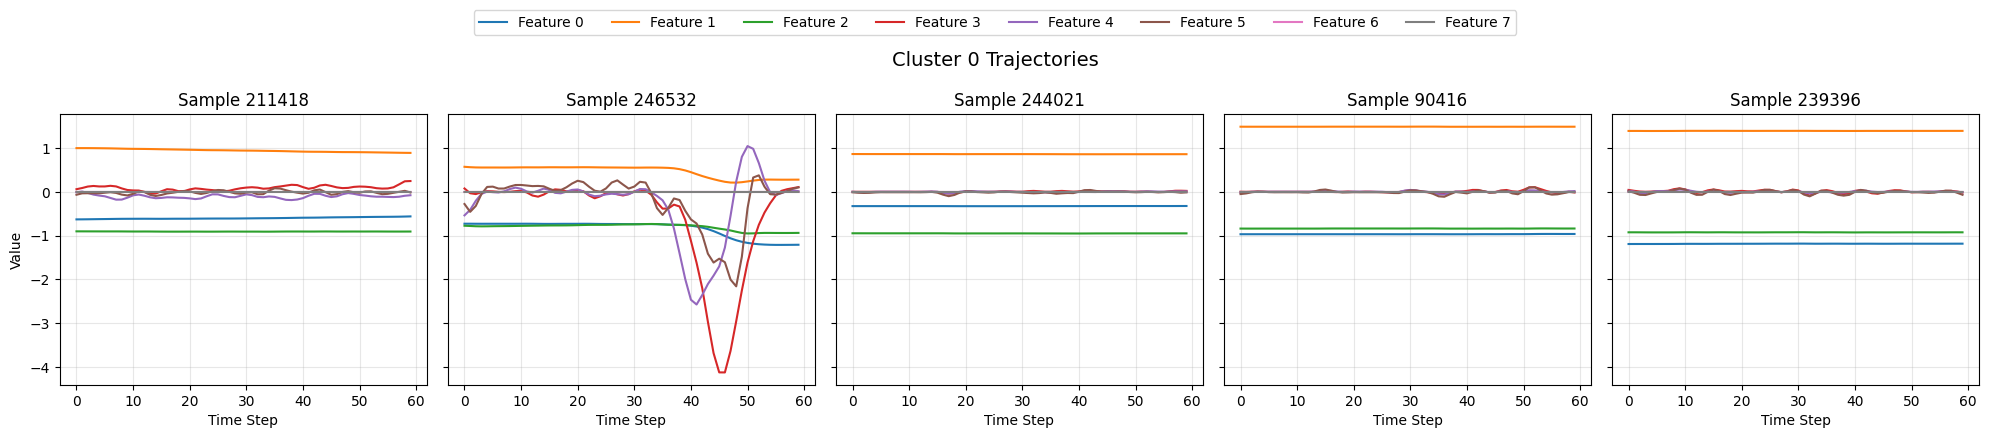

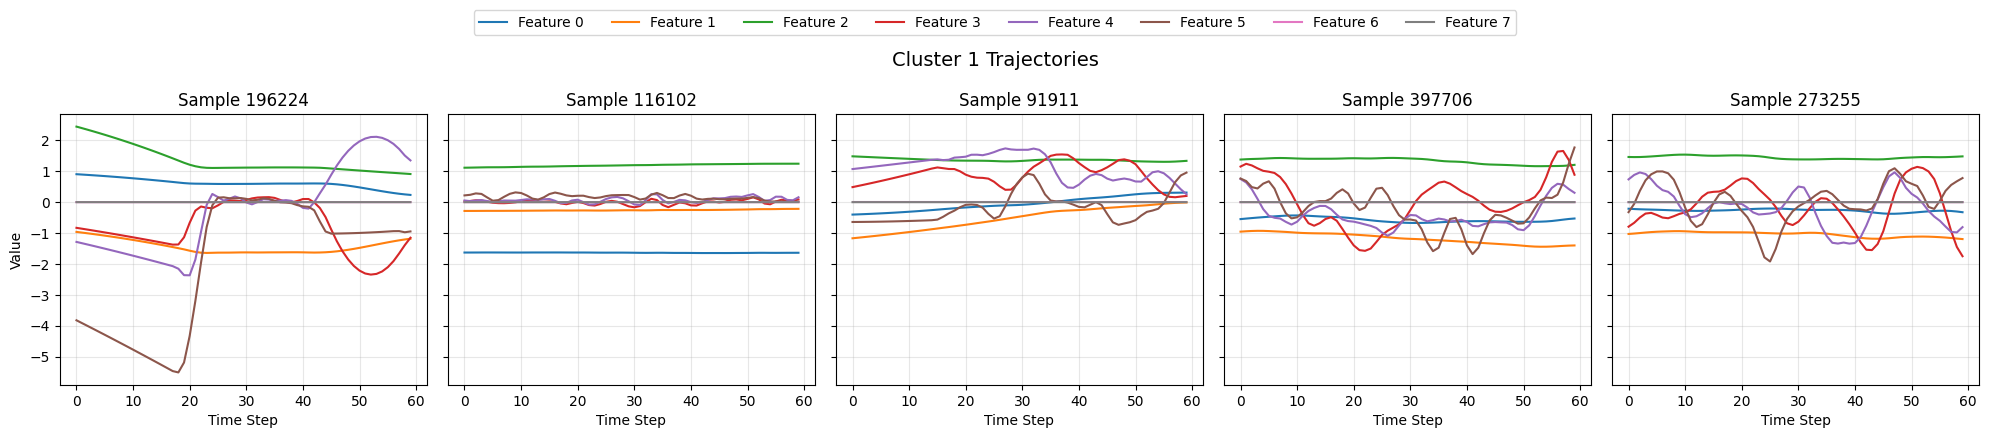

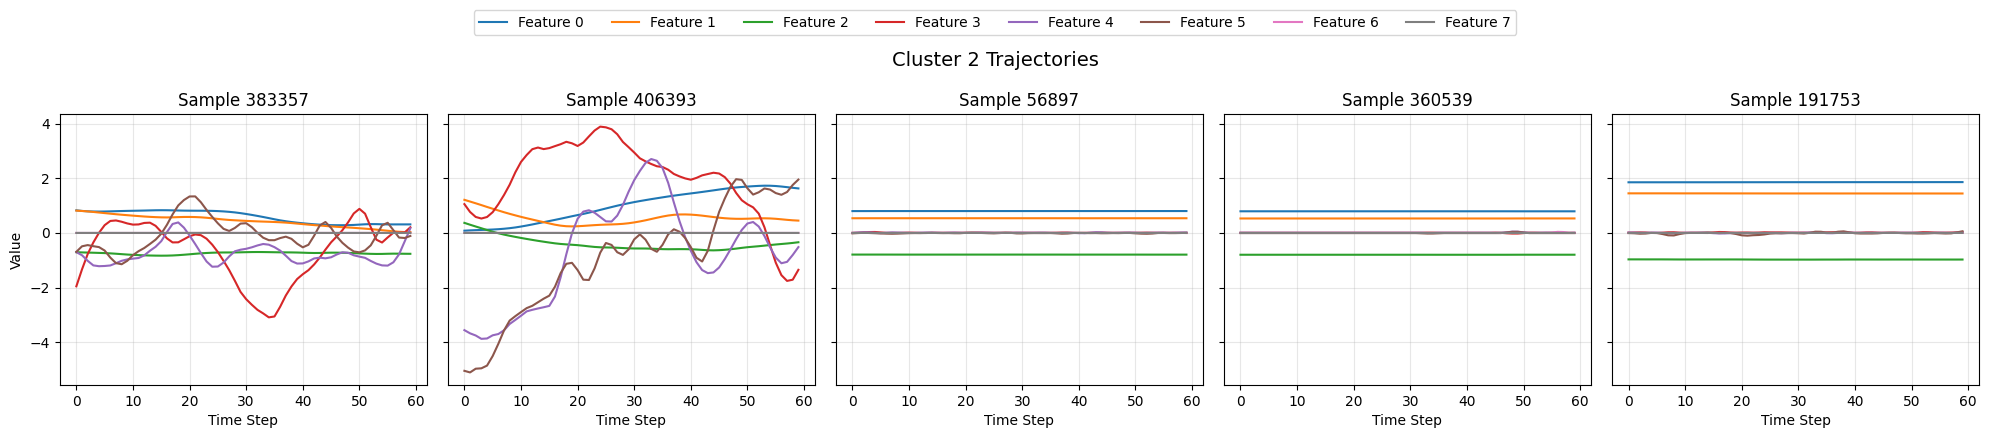

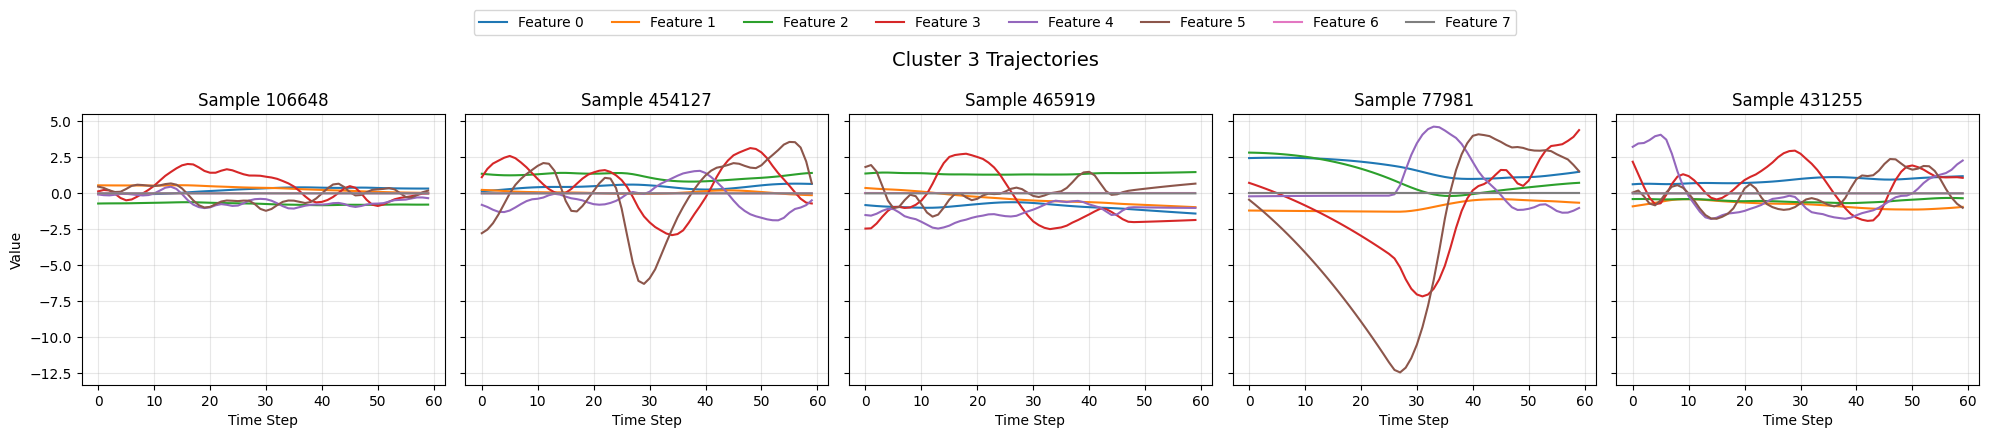

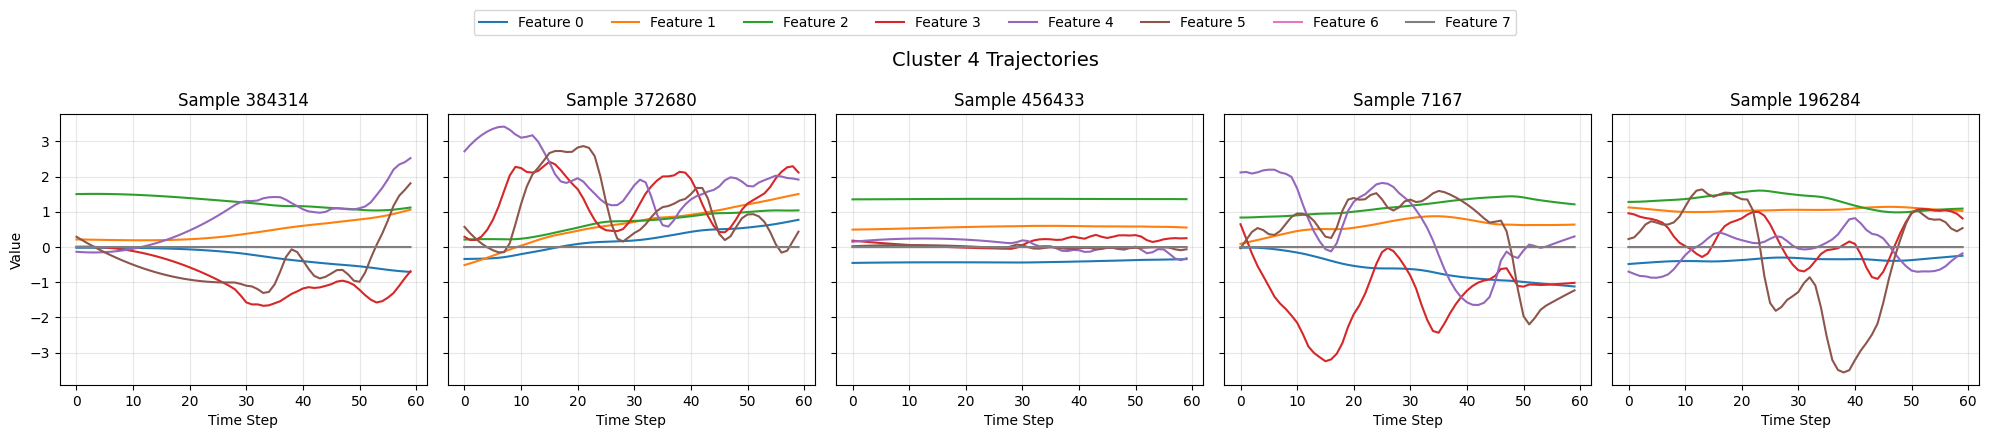

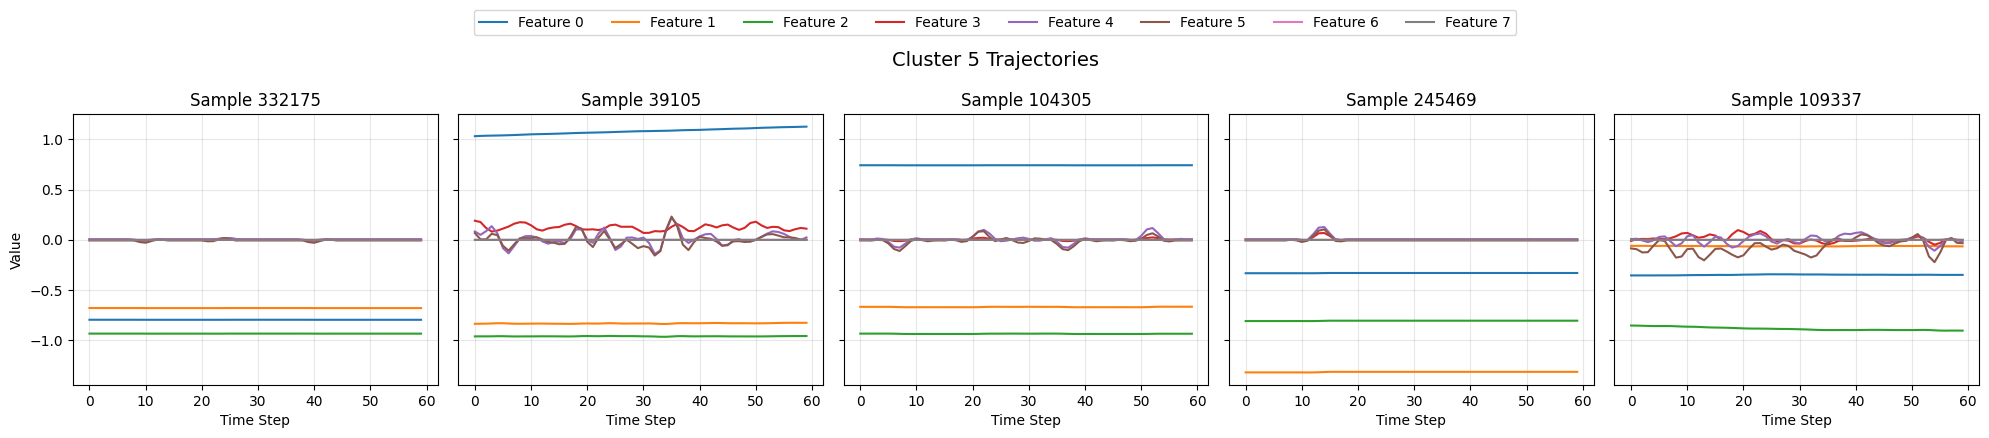

In [ ]:
def plot_cluster_trajectories(cluster_id, num_examples=5, feature_names=None):
    indices = np.where(labels == cluster_id)[0]
    chosen = np.random.choice(indices, size=num_examples, replace=False)

    fig, axes = plt.subplots(1, num_examples, figsize=(20, 4), sharey=True)
    if num_examples == 1:
        axes = [axes]  # Ensure iterable if only one plot

    for i, idx in enumerate(chosen):
        traj = tensor_data[idx].numpy()  # shape (8, 60)

        for f in range(traj.shape[0]):
            axes[i].plot(range(traj.shape[1]), traj[f], label=feature_names[f] if feature_names else f"Feature {f}")

        axes[i].set_title(f"Sample {idx}")
        axes[i].set_xlabel("Time Step")
        if i == 0:
            axes[i].set_ylabel("Value")
        axes[i].grid(True, alpha=0.3)

    if feature_names:
        fig.legend(feature_names, loc="upper center", ncol=len(feature_names), bbox_to_anchor=(0.5, 1.1))

    plt.suptitle(f"Cluster {cluster_id} Trajectories", fontsize=14)
    plt.tight_layout()
    plt.show()

# Example usage
feature_names = [f"Feature {i}" for i in range(8)]  # Replace with real names if known
for c in range(BEST_K):
    plot_cluster_trajectories(c, num_examples=5, feature_names=feature_names)


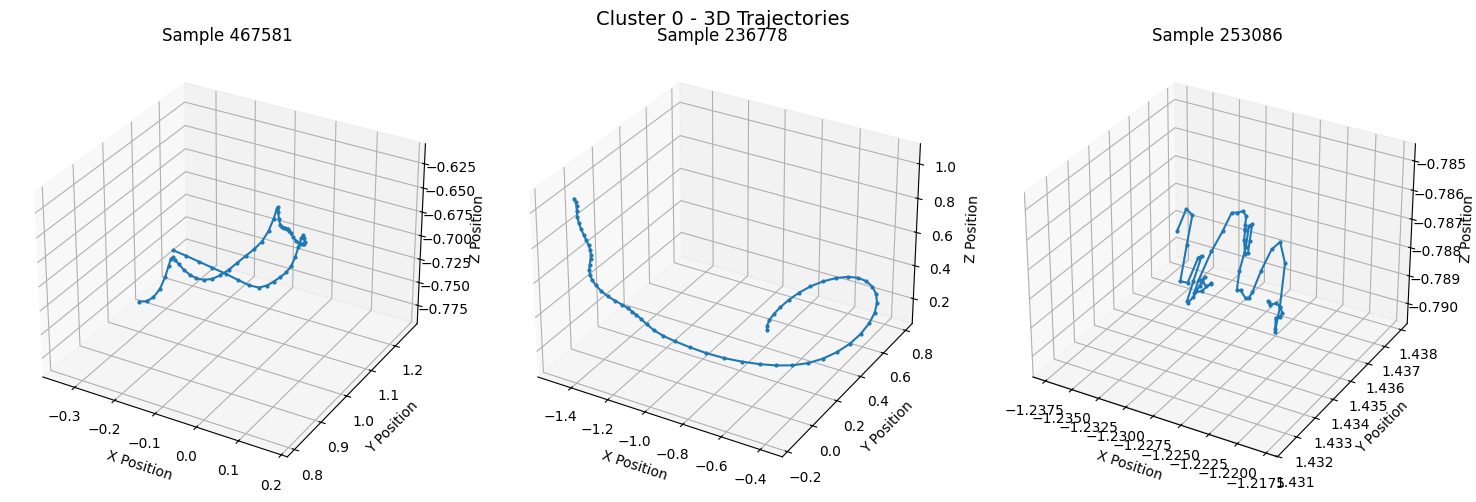

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

def plot_cluster_trajectories_3d(cluster_id, num_examples=3, xyz_indices=(0, 1, 2)):
    indices = np.where(labels == cluster_id)[0]
    chosen = np.random.choice(indices, size=num_examples, replace=False)

    fig = plt.figure(figsize=(15, 5))
    
    for i, idx in enumerate(chosen, 1):
        traj = tensor_data[idx].numpy()  # shape (8, 60)
        
        xs = traj[xyz_indices[0]]
        ys = traj[xyz_indices[1]]
        zs = traj[xyz_indices[2]]

        ax = fig.add_subplot(1, num_examples, i, projection='3d')
        ax.plot(xs, ys, zs, marker='o', markersize=2)
        ax.set_title(f"Sample {idx}")
        ax.set_xlabel("X Position")
        ax.set_ylabel("Y Position")
        ax.set_zlabel("Z Position")

    plt.suptitle(f"Cluster {cluster_id} - 3D Trajectories", fontsize=14)
    plt.tight_layout()
    plt.show()

# Example usage (assuming features 0, 1, 2 are X, Y, Z coordinates)
plot_cluster_trajectories_3d(cluster_id=0, num_examples=3, xyz_indices=(0, 1, 2))


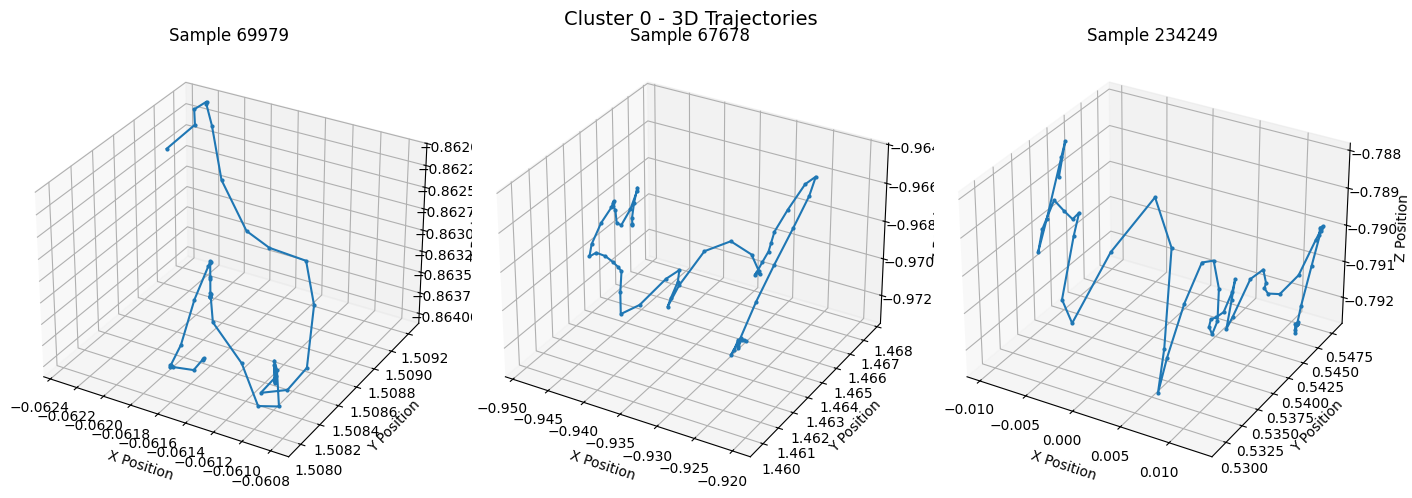

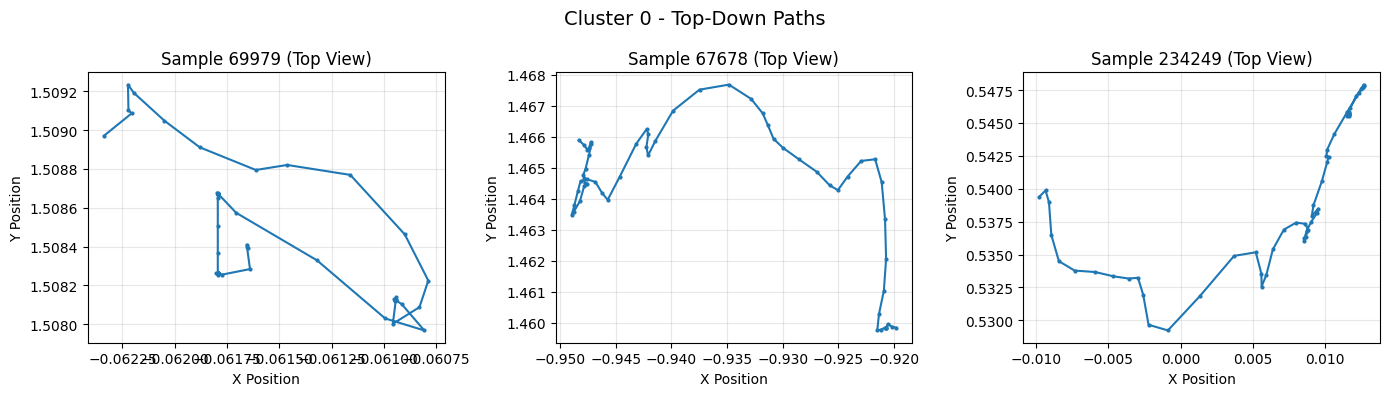

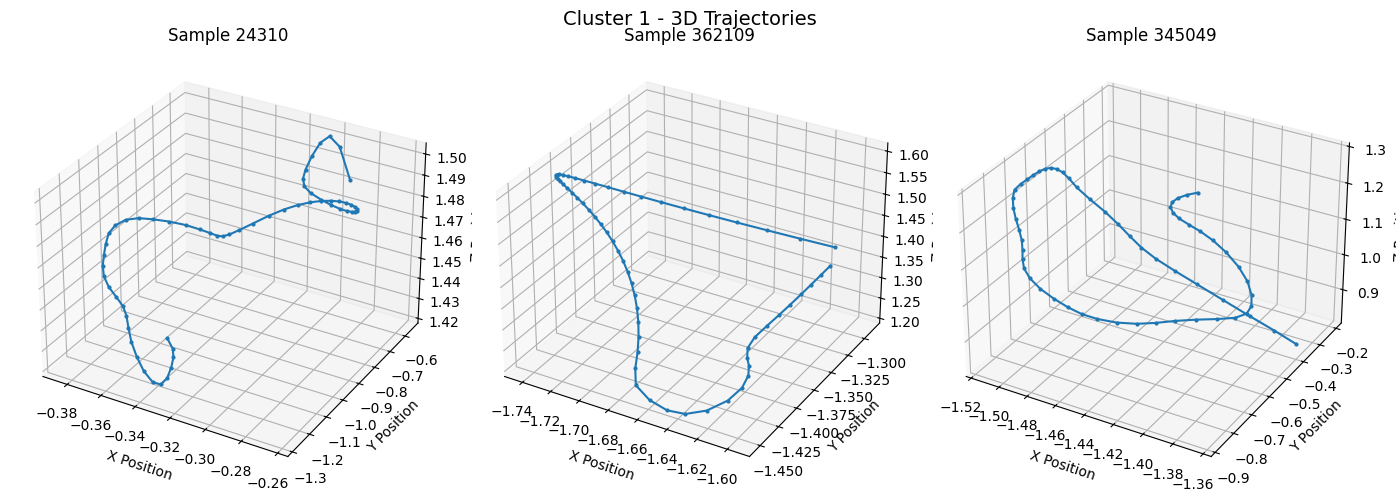

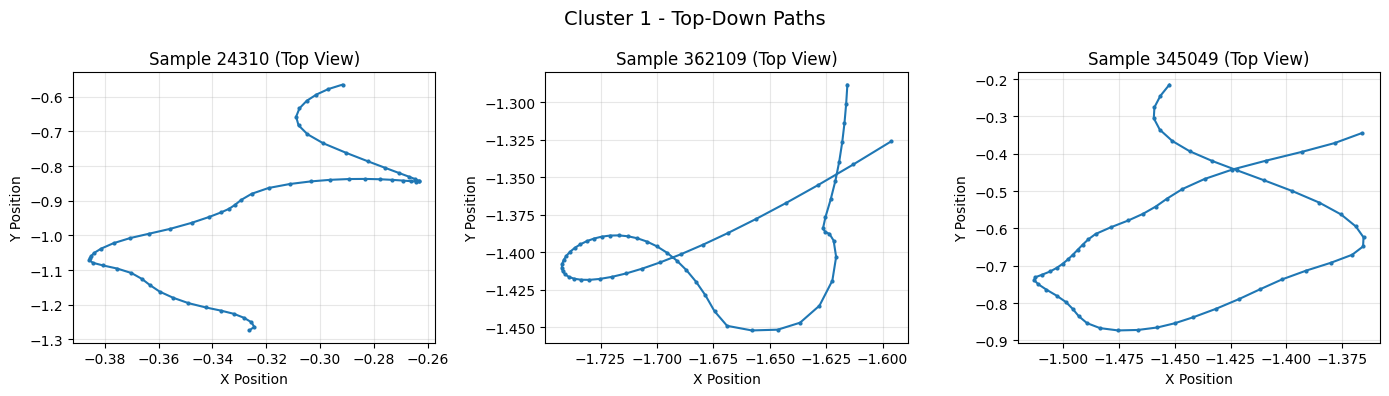

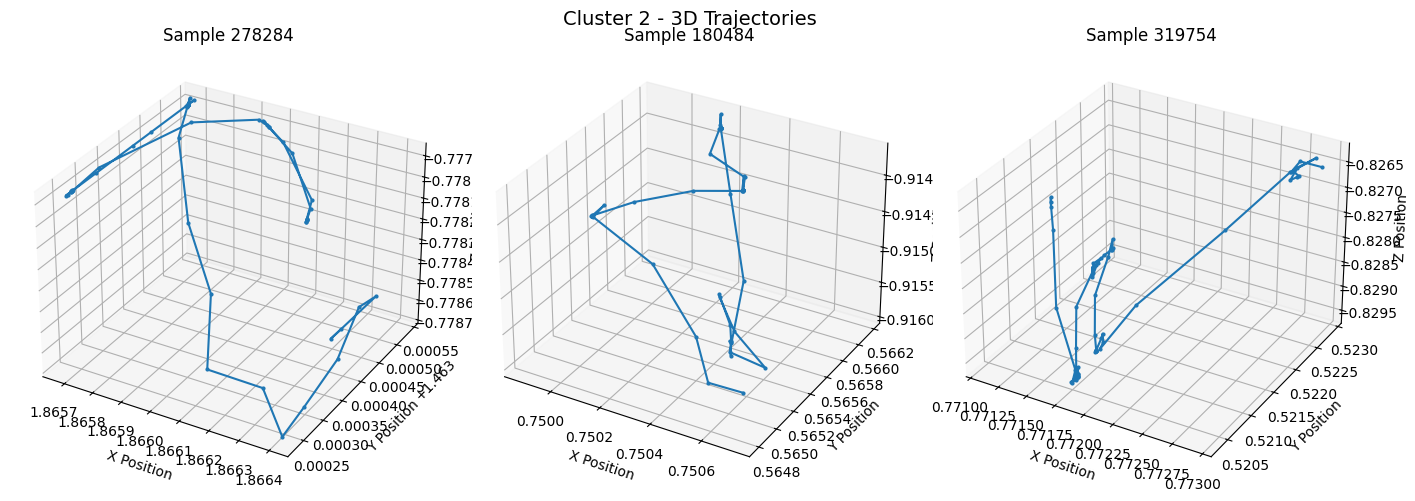

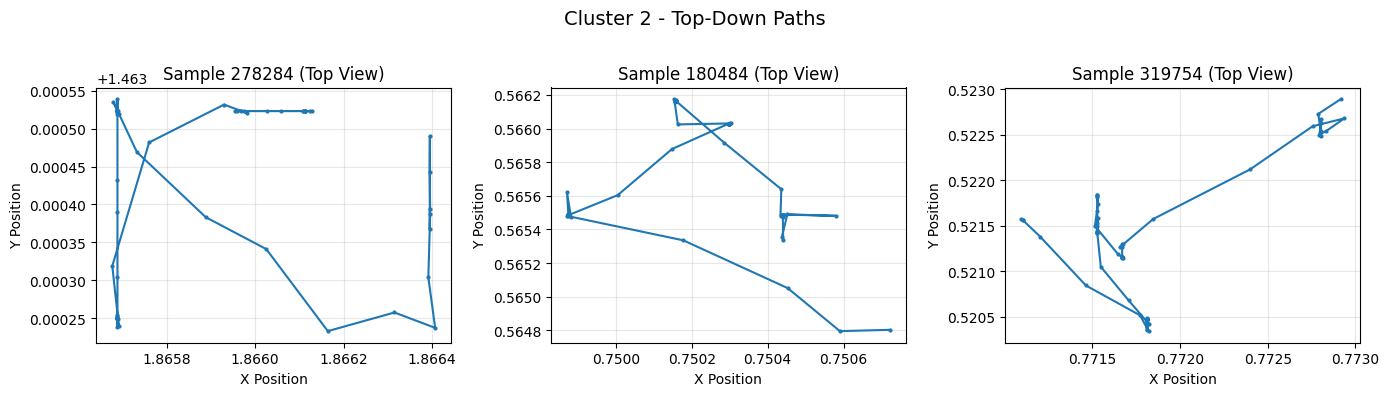

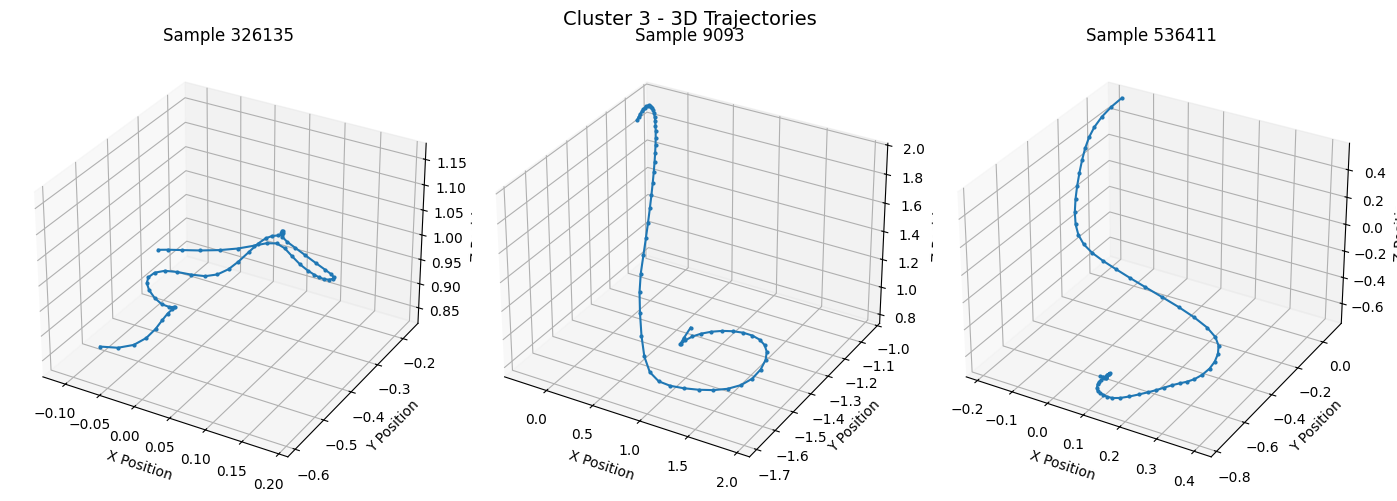

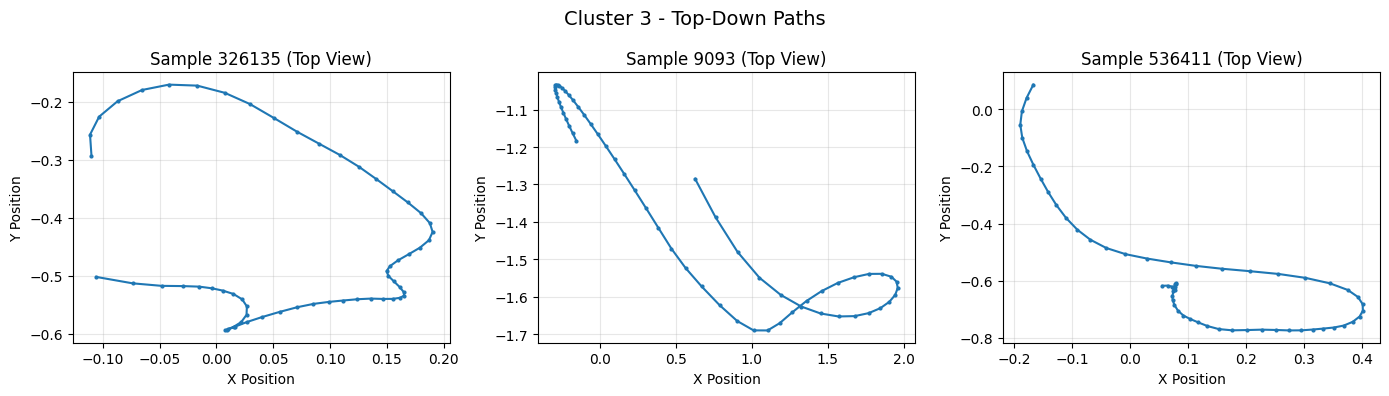

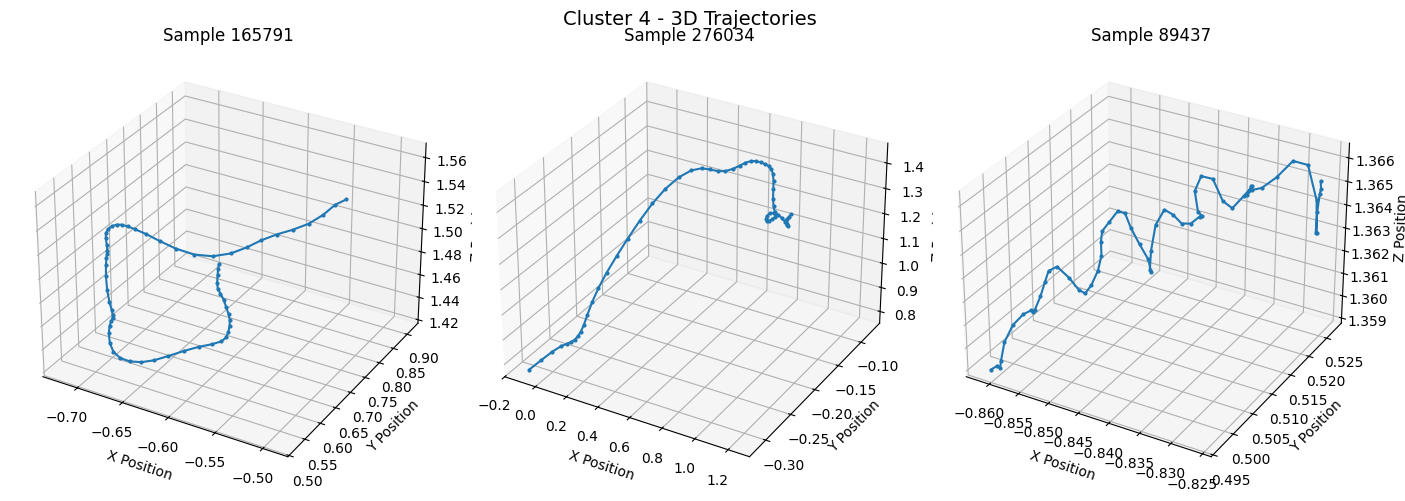

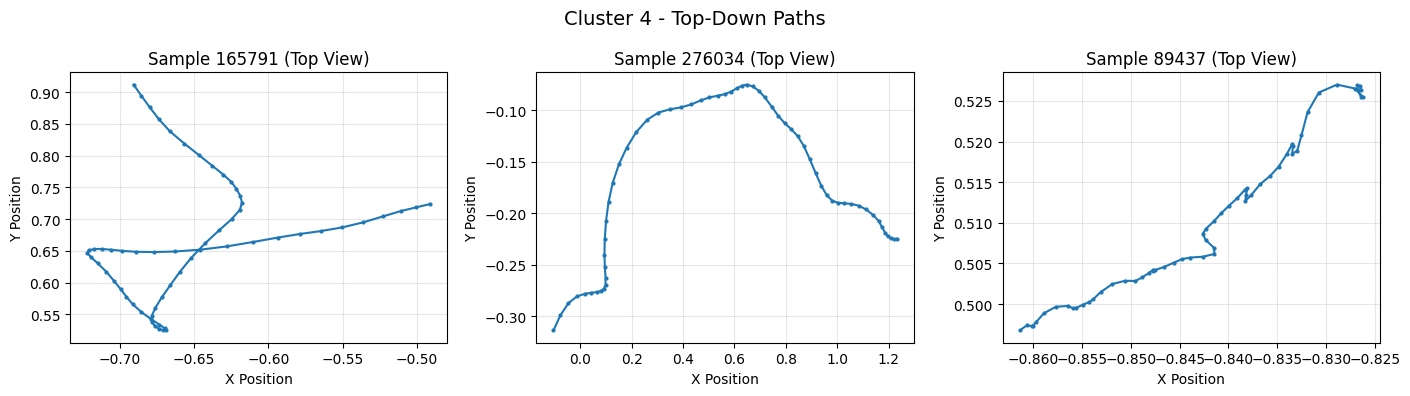

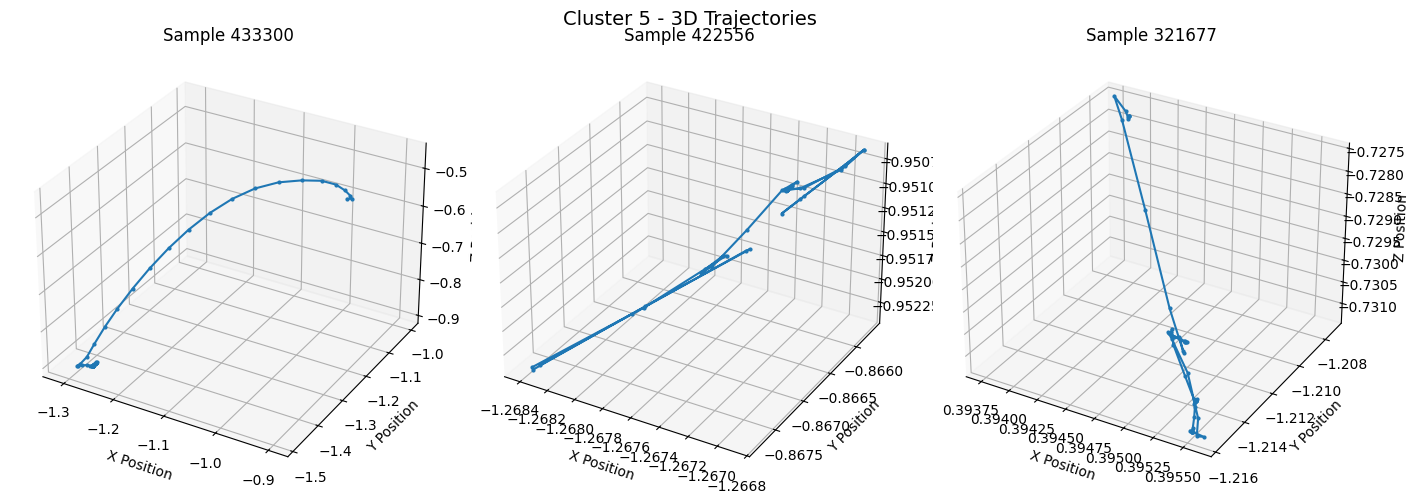

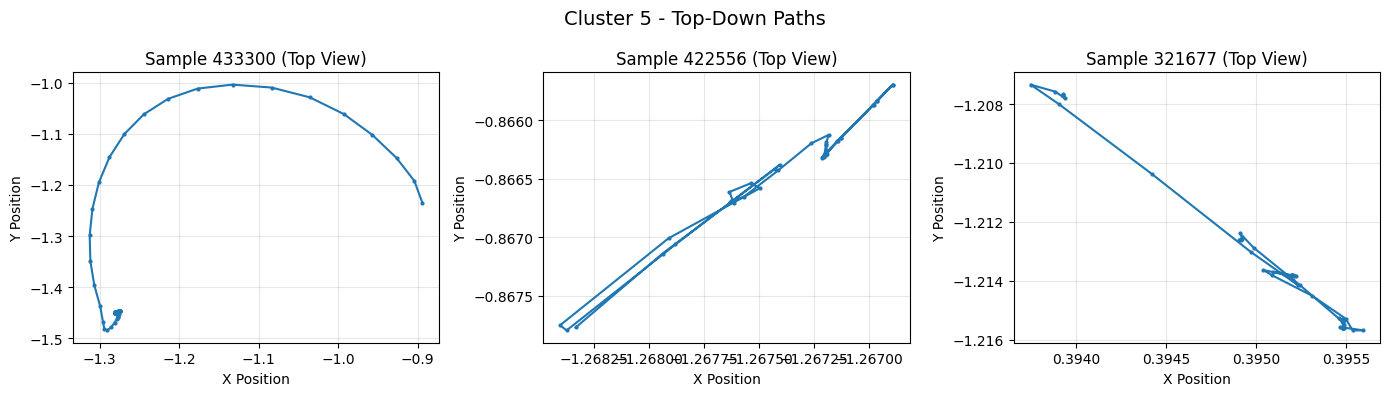

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_cluster_paths(cluster_id, num_examples=3, xyz_indices=(0, 1, 2)):
    indices = np.where(labels == cluster_id)[0]
    chosen = np.random.choice(indices, size=num_examples, replace=False)

    fig = plt.figure(figsize=(14, 5))

    # --- 3D Plot ---
    for i, idx in enumerate(chosen, 1):
        traj = tensor_data[idx].numpy()  # shape (8, 60)
        xs = traj[xyz_indices[0]]
        ys = traj[xyz_indices[1]]
        zs = traj[xyz_indices[2]]

        ax = fig.add_subplot(1, num_examples, i, projection='3d')
        ax.plot(xs, ys, zs, marker='o', markersize=2)
        ax.set_title(f"Sample {idx}")
        ax.set_xlabel("X Position")
        ax.set_ylabel("Y Position")
        ax.set_zlabel("Z Position")

    plt.suptitle(f"Cluster {cluster_id} - 3D Trajectories", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"cluster_{cluster_id}_3D.png", dpi=300)
    plt.show()

    # --- 2D Top-Down Projection ---
    fig, axes = plt.subplots(1, num_examples, figsize=(14, 4))
    if num_examples == 1:
        axes = [axes]

    for i, idx in enumerate(chosen):
        traj = tensor_data[idx].numpy()
        xs = traj[xyz_indices[0]]
        ys = traj[xyz_indices[1]]

        axes[i].plot(xs, ys, marker='o', markersize=2)
        axes[i].set_title(f"Sample {idx} (Top View)")
        axes[i].set_xlabel("X Position")
        axes[i].set_ylabel("Y Position")
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(f"Cluster {cluster_id} - Top-Down Paths", fontsize=14)
    plt.tight_layout()
    plt.show()

# Run for all clusters
for c in range(BEST_K):
    plot_cluster_paths(c, num_examples=3, xyz_indices=(0, 1, 2))


[INFO] Selected bees for plotting: ['Bee28', 'Bee22', 'Bee18']


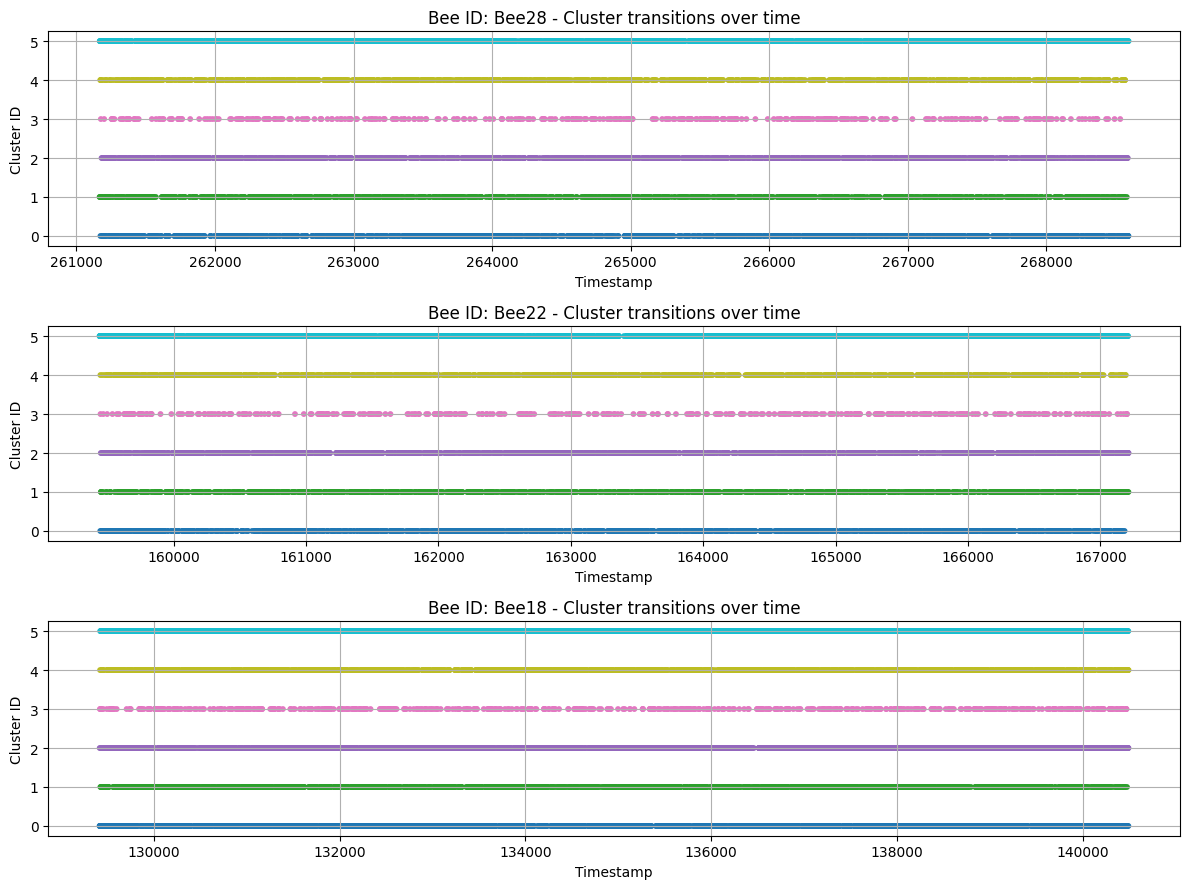

C:\Users\hm594\AppData\local\Temp\ipykernel_11812\2083101990.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


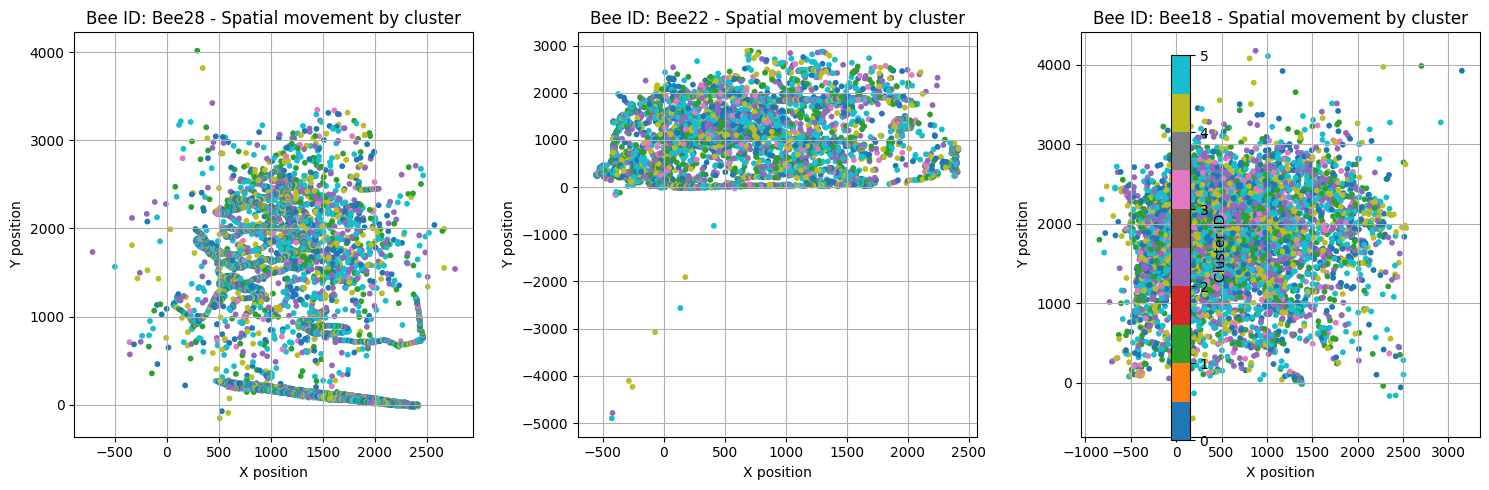

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------------------
# Load cluster map
# -----------------------------------------
df_map = pd.read_csv("bee_cluster_mapD.csv")

# -----------------------------------------
# Load original data
# -----------------------------------------
with open("bee_samples_with_ids.pkl", "rb") as f:
    data_dict = pickle.load(f)

segments = np.array(data_dict["segments"])  # shape: (N, 8, 60)
bee_ids = np.array(data_dict["bee_ids"])        # shape: (N,)
timestamps = np.array(data_dict.get("timestamps", np.arange(len(bee_ids))))  # fallback to index order

df_map["timestamp"] = timestamps
df_map["x"] = [seg[0, 0] for seg in segments]  # first time step's x
df_map["y"] = [seg[1, 0] for seg in segments]  # first time step's y

# -----------------------------------------
# Pick a few bees for plotting
# -----------------------------------------
num_bees_to_plot = 3
unique_bees = df_map["bee_id"].unique()
selected_bees = random.sample(list(unique_bees), num_bees_to_plot)
print(f"[INFO] Selected bees for plotting: {selected_bees}")

# -----------------------------------------
# 1. Timeline plots
# -----------------------------------------
fig, axes = plt.subplots(num_bees_to_plot, 1, figsize=(12, 3*num_bees_to_plot), sharex=False)

if num_bees_to_plot == 1:
    axes = [axes]  # make iterable

for ax, bee in zip(axes, selected_bees):
    bee_data = df_map[df_map["bee_id"] == bee].sort_values("timestamp")
    ax.scatter(bee_data["timestamp"], bee_data["cluster_id"], c=bee_data["cluster_id"], cmap="tab10", s=10)
    ax.set_title(f"Bee ID: {bee} - Cluster transitions over time")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Cluster ID")
    ax.grid(True)

plt.tight_layout()
plt.show()

# -----------------------------------------
# 2. Spatial plots
# -----------------------------------------
fig, axes = plt.subplots(1, num_bees_to_plot, figsize=(5*num_bees_to_plot, 5), sharex=False, sharey=False)

if num_bees_to_plot == 1:
    axes = [axes]

for ax, bee in zip(axes, selected_bees):
    bee_data = df_map[df_map["bee_id"] == bee]
    sc = ax.scatter(bee_data["x"], bee_data["y"], c=bee_data["cluster_id"], cmap="tab10", s=10)
    ax.set_title(f"Bee ID: {bee} - Spatial movement by cluster")
    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.grid(True)

fig.colorbar(sc, ax=axes, label="Cluster ID")
plt.tight_layout()
plt.show()


[INFO] Selected bees for plotting: ['Bee10', 'Bee14', 'Bee49']


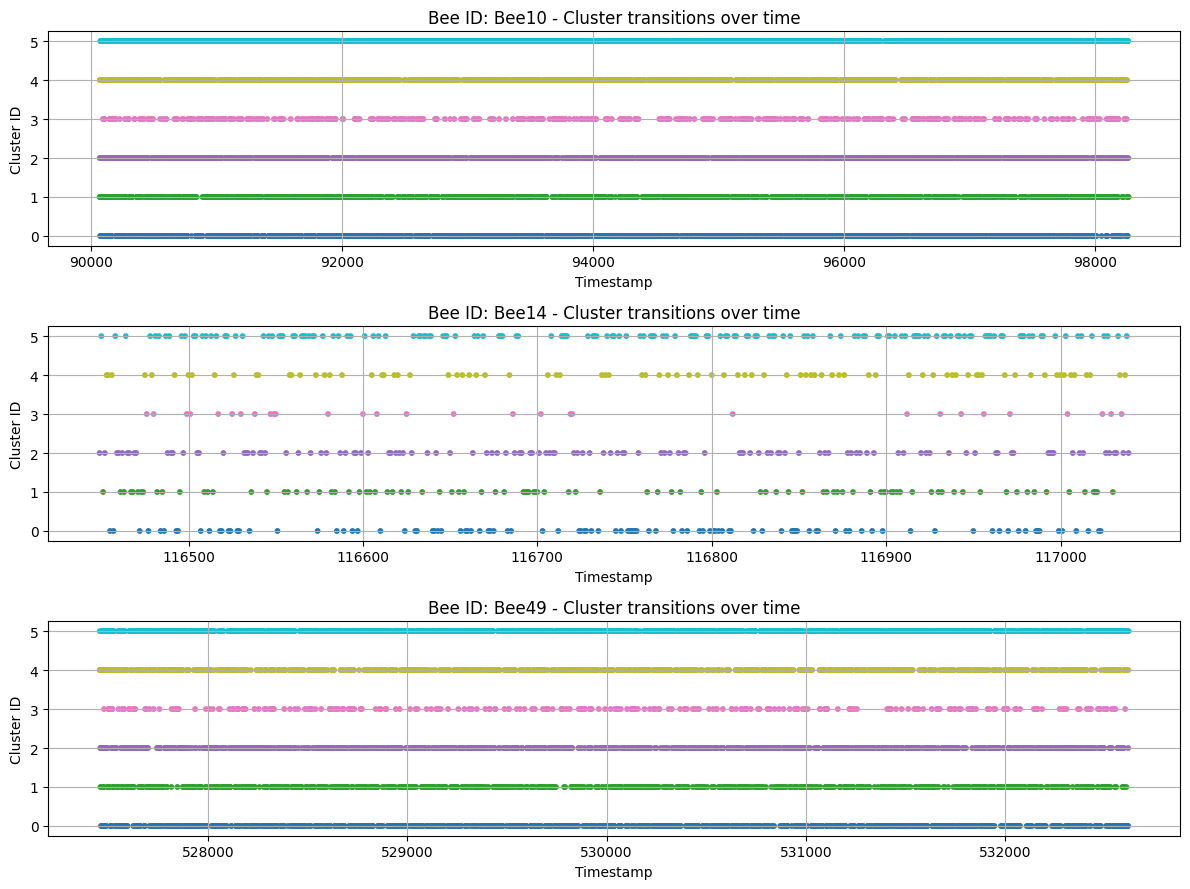

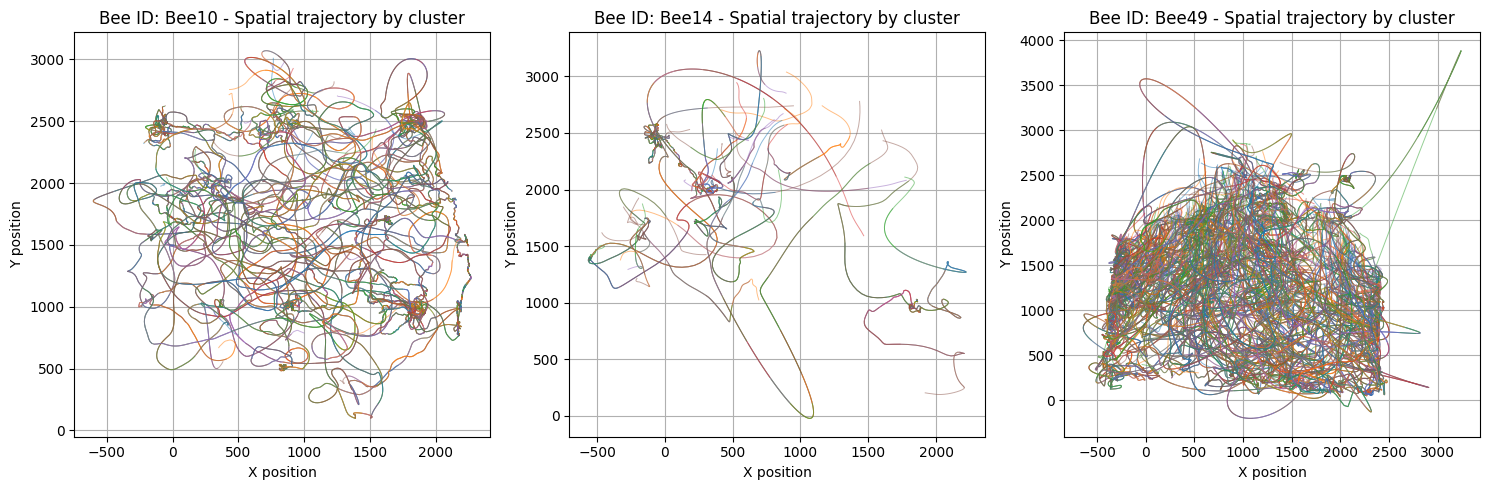

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------------------
# Load cluster map
# -----------------------------------------
df_map = pd.read_csv("bee_cluster_map.csv")

# -----------------------------------------
# Load original data
# -----------------------------------------
with open("bee_samples_with_ids.pkl", "rb") as f:
    data_dict = pickle.load(f)

segments = np.array(data_dict["segments"])  # shape: (N, 8, 60)
bee_ids = np.array(data_dict["bee_ids"])        # shape: (N,)
timestamps = np.array(data_dict.get("timestamps", np.arange(len(bee_ids))))  # fallback to index order

df_map["timestamp"] = timestamps

# -----------------------------------------
# Pick a few bees for plotting
# -----------------------------------------
num_bees_to_plot = 3
unique_bees = df_map["bee_id"].unique()
selected_bees = random.sample(list(unique_bees), num_bees_to_plot)
print(f"[INFO] Selected bees for plotting: {selected_bees}")

# -----------------------------------------
# 1. Timeline plots
# -----------------------------------------
fig, axes = plt.subplots(num_bees_to_plot, 1, figsize=(12, 3*num_bees_to_plot), sharex=False)

if num_bees_to_plot == 1:
    axes = [axes]  # make iterable

for ax, bee in zip(axes, selected_bees):
    bee_data = df_map[df_map["bee_id"] == bee].sort_values("timestamp")
    ax.scatter(bee_data["timestamp"], bee_data["cluster_id"], c=bee_data["cluster_id"], cmap="tab10", s=10)
    ax.set_title(f"Bee ID: {bee} - Cluster transitions over time")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Cluster ID")
    ax.grid(True)

plt.tight_layout()
plt.show()

# -----------------------------------------
# 2. Spatial trajectory plots (full 60 steps per segment)
# -----------------------------------------
fig, axes = plt.subplots(1, num_bees_to_plot, figsize=(5*num_bees_to_plot, 5), sharex=False, sharey=False)

if num_bees_to_plot == 1:
    axes = [axes]

for ax, bee in zip(axes, selected_bees):
    bee_indices = np.where(df_map["bee_id"] == bee)[0]

    for idx in bee_indices:
        cluster_id = df_map.iloc[idx]["cluster_id"]
        x_traj = segments[idx, 0, :]  # all 60 timesteps x
        y_traj = segments[idx, 1, :]  # all 60 timesteps y
        ax.plot(x_traj, y_traj, color=plt.cm.tab10(cluster_id), alpha=0.5, linewidth=0.7)

    ax.set_title(f"Bee ID: {bee} - Spatial trajectory by cluster")
    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.grid(True)

plt.tight_layout()
plt.show()


[INFO] Selected bees for plotting: ['Bee52', 'Bee3', 'Bee47']


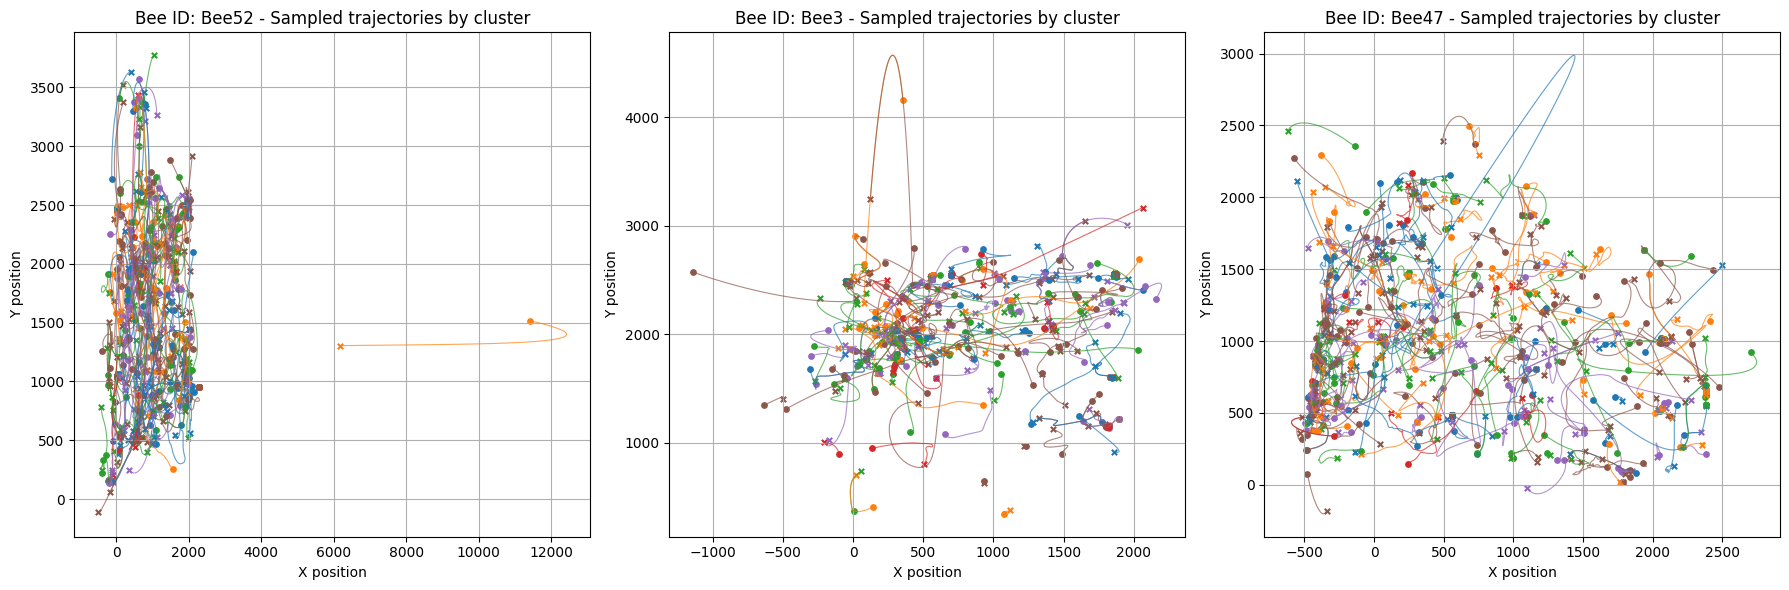

In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------------------
# Load cluster mapping
# -----------------------------------------
df_map = pd.read_csv("bee_cluster_map.csv")

# -----------------------------------------
# Load original data
# -----------------------------------------
with open("bee_samples_with_ids.pkl", "rb") as f:
    data_dict = pickle.load(f)

segments = np.array(data_dict["segments"])  # shape: (N, 8, 60)
bee_ids = np.array(data_dict["bee_ids"])        # shape: (N,)
timestamps = np.array(data_dict.get("timestamps", np.arange(len(bee_ids))))

df_map["timestamp"] = timestamps

# -----------------------------------------
# Settings
# -----------------------------------------
MAX_SEGMENTS_PER_BEE = 400
num_bees_to_plot = 3
cmap = plt.cm.tab10

# Pick random bees
unique_bees = df_map["bee_id"].unique()
selected_bees = random.sample(list(unique_bees), num_bees_to_plot)
print(f"[INFO] Selected bees for plotting: {selected_bees}")

# -----------------------------------------
# Plot
# -----------------------------------------
fig, axes = plt.subplots(1, num_bees_to_plot, figsize=(6*num_bees_to_plot, 6), sharex=False, sharey=False)

if num_bees_to_plot == 1:
    axes = [axes]

for ax, bee in zip(axes, selected_bees):
    bee_indices = np.where(df_map["bee_id"] == bee)[0]

    # Subsample to reduce clutter
    if len(bee_indices) > MAX_SEGMENTS_PER_BEE:
        bee_indices = np.random.choice(bee_indices, MAX_SEGMENTS_PER_BEE, replace=False)

    for idx in bee_indices:
        cluster_id = df_map.iloc[idx]["cluster_id"]
        x_traj = segments[idx, 0, :]
        y_traj = segments[idx, 1, :]

        # Plot trajectory with arrow to show direction
        ax.plot(x_traj, y_traj, color=cmap(cluster_id), alpha=0.7, linewidth=0.8)
        ax.scatter(x_traj[0], y_traj[0], color=cmap(cluster_id), marker="o", s=15)  # Start
        ax.scatter(x_traj[-1], y_traj[-1], color=cmap(cluster_id), marker="x", s=15) # End

    ax.set_title(f"Bee ID: {bee} - Sampled trajectories by cluster")
    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import pickle

# Path to your pickle file
file_path = "bee_samples_with_ids.pkl"

# Load the pickle file
with open(file_path, "rb") as f:
    data = pickle.load(f)

# Confirm it's a dictionary
print("Type:", type(data))

if isinstance(data, dict):
    # See keys
    print("Keys:", data.keys())

    # Check one example key's value
    first_key = next(iter(data))
    print(f"\nExample key: {first_key}")
    print(f"Value type: {type(data[first_key])}")

    # If values are arrays/lists, you can inspect shape/length
    try:
        print("Shape:", data[first_key].shape)
    except AttributeError:
        try:
            print("Length:", len(data[first_key]))
        except:
            pass

    # # Print first few items for inspection
    # for k, v in list(data.items())[:3]:  # first 3 key-value pairs
    #     print(f"\nKey: {k}")
    #     print(f"Value preview: {str(v)[:200]}")  # first 200 chars


Type: <class 'dict'>
Keys: dict_keys(['segments', 'bee_ids', 'start_times'])

Example key: segments
Value type: <class 'list'>
Length: 540278


Visualising clustered behaviours
We can sweep through the entire trajectory for each bee, providing short segments of the trajectory to the NN as inputs, obtaining the hidden/output layer representation, determining the cluster (i.e. behavioural motif) to which the representation belongs, and assigning that behaviour a colour. Following this method, we can assign a cluster (behavioural motif) to every time point in the trajectory, and plot it using the colour codes, to visualise how one behaviour transitions into another, and into yet another, during the entire recording of that bee.

In [ ]:
print("Trajectory time values:", df[df["bee_id"] == "Bee12"]["time"].head(10).to_list())
print("Sample start times:", map_df[map_df["bee_id"] == "Bee12"]["start_time"].head(10).to_list())


Trajectory time values: [0.234, 0.2673333333333333, 0.3006666666666667, 0.3340000000000001, 0.3673333333333334, 0.4006666666666668, 0.4340000000000001, 0.4673333333333335, 0.5006666666666668, 0.5340000000000001]
Sample start times: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]
